# Calidad del Aire y Salud Respiratoria
## Región Metropolitana de Chile, 2020–2024

### Grupo 5

---

## 1. Introducción

Este notebook integra el EDA respiratorio y el análisis estadístico/ML en un flujo único, estructurado en torno a las seis preguntas de investigación del proyecto. Combina series temporales, análisis de correlación, técnicas supervisadas y no supervisadas, y diseños cuasi-experimentales para obtener una visión integral de la relación entre contaminación atmosférica y salud respiratoria en la Región Metropolitana.

---

## 2. Preguntas de Investigación

| # | Pregunta | Técnicas |
|---|---|---|
| **P1** | Asociación contaminantes–urgencias | Series temporales, Kruskal-Wallis, Spearman |
| **P2** | Impacto relativo y no linealidades | Mutual Information, PCA, categorías de riesgo |
| **P3** | Efectos rezagados | Correlación cruzada con lags 0–4 semanas |
| **P4** | Patrones espaciales y clusters | Análisis espacial PM10, K-means perfiles de enfermedad |
| **P5** | Predicción de días de alto riesgo | Regresión Logística, Árbol de Decisión (GridSearchCV) |
| **P6** | Umbrales normativos y efectos causales | Detección de episodios, DiD, Regression Discontinuity |

---

## 3. Datos

### 3.1 Fuentes de datos

**Calidad del aire** — [MinCiencia / Datos-CambioClimatico](https://github.com/MinCiencia/Datos-CambioClimatico)

- Contaminantes: PM10, PM2.5, NO₂, O₃, SO₂
- Archivos: `data/Datos-CambioClimatico/output/{contaminante}/{año}/{año}_{contaminante}_sinca.csv` (uno por contaminante por año, 2020–2024)
- Filtro espacial: bounding box RM (lat −34° a −33°, lon −71.1° a −70°)
- Caché: `data/Datos-CambioClimatico/air_santiago_2020_2024.parquet`

**Atenciones de urgencia** — [DEIS/MINSAL](https://deis.minsal.cl/#datosabiertos)

- Archivos: `data/urgencias/AtencionesUrgencia{año}.csv` para 2020–2024 (~6 GB en total)
- Filtro RM: los archivos 2020–2022 no incluyen `NombreRegion`; se derivan los IDs de establecimientos RM desde el archivo 2023 y se aplican a todos los años
- Columnas retenidas: `IdEstablecimiento, NEstablecimiento, GlosaCausa, Total, Menores_1, De_1_a_4, De_5_a_14, De_15_a_64, De_65_y_mas, fecha, semana, GLOSATIPOESTABLECIMIENTO, NombreRegion`
- Caché: `data/urgencias/urgencia_2020_2024.parquet`

**Estadísticas hospitalarias** — [DEIS/MINSAL](https://deis.minsal.cl/#datosabiertos)

- Archivo consolidado (2020–2023): `data/estadisticas_hospitalarias/Consolidado Estadísticas Hospitalarias 2014-2023.xlsx` (una hoja por año, encabezado en fila 2)
- Archivo 2024: `data/estadisticas_hospitalarias/Estadísticas Hospitalarias Año 2024.xlsx` (hoja "Año 2024")
- Filtro RM: columna `Nombre SS/SEREMI` comienza con `"Metropolitano"` y `Cód. Nivel Cuidado ≠ 0`
- Caché: `data/estadisticas_hospitalarias/hospitalaria_2020_2024.parquet`

**Defunciones** — [DEIS/MINSAL](https://deis.minsal.cl/#datosabiertos)

- Archivo histórico: `data/defunciones/DEFUNCIONES_FUENTE_DEIS_1990_2022_CIFRAS_OFICIALES.csv` (794 MB; se filtran años 2020–2022)
- Archivo reciente: `data/defunciones/DEFUNCIONES_FUENTE_DEIS_2023_2026_31032026.csv` (117 MB; se filtran años 2023–2024)
- Caché: `data/defunciones/defunciones_2020_2024.parquet`

**Catálogo de establecimientos** — MINSAL REAS

- Archivo: `data/establecimientos_20260428.csv` (1 069 establecimientos RM con coordenadas georreferenciadas)
- Usado para análisis espacial: join KDTree al establecimiento de urgencia más cercano a cada estación de monitoreo
- No se cachea (archivo pequeño, carga instantánea)

### 3.2 Preprocesamiento

- Todos los datasets se cargan desde caché Parquet vía `%run exploration_optimized.ipynb`
- Filtro a causas respiratorias por `GlosaCausa` (regex: `RESPIRAT|IRA Alta|BRONQUIT|INFLUENZA|NEUMON|ASMA|EPOC`)
- Agregación diaria/semanal; construcción de series alineadas por (año, semana ISO)

---

In [1]:
%%capture
%run exploration_optimized.ipynb

In [2]:
import matplotlib.dates as mdates
from scipy.stats import shapiro, kstest, probplot, spearmanr, kruskal
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

# Respiratory cause filter — consistent with exploration_optimized
RESP_TOTAL = "TOTAL CAUSAS SISTEMA RESPIRATORIO"
RESP_PATTERN = r"RESPIRAT|IRA\s*Alta|BRONQUIT|INFLUENZA|NEUMON|ASMA|EPOC"

# Convenience: full respiratory subset (all years, all causes)
data = df_urgencia_rm[df_urgencia_rm["GlosaCausa"].str.contains(RESP_PATTERN, case=False, na=False)].copy()
data["fecha_dt"] = pd.to_datetime(data["fecha"], dayfirst=True)

print(f"df_air         : {df_air.shape}  ({df_air['time'].min().date()} → {df_air['time'].max().date()})")
print(f"df_urgencia_rm : {df_urgencia_rm.shape}")
print(f"data (resp)    : {data.shape}  — {data['GlosaCausa'].nunique()} causas respiratorias")
print(f"df_estab_rm    : {df_estab_rm.shape}")
print(f"POLLUTANTS     : {POLLUTANTS}")

df_air         : (426982, 10)  (2020-01-01 → 2024-12-18)
df_urgencia_rm : (10259080, 14)
data (resp)    : (1853978, 15)  — 7 causas respiratorias
df_estab_rm    : (1069, 38)
POLLUTANTS     : ['mpm10', 'mpm25', 'no2', 'o3', 'so2']


---

## 4. P1 — Asociación Contaminantes–Urgencias

**Pregunta:** ¿Existe una asociación significativa entre los niveles diarios de contaminantes atmosféricos (PM2.5, PM10, NO₂, O₃, SO₂) y las atenciones de urgencia por enfermedades respiratorias en la Región Metropolitana?

### 4.1 Estrategia

- Series de tiempo diaria y semanal del total respiratorio (2020–2024)
- Desagregación por tipo de causa y por rango etario
- Test de normalidad (Shapiro-Wilk, Kolmogorov-Smirnov) → justifica pruebas no paramétricas
- Kruskal-Wallis estacional sobre contaminantes y urgencias
- Correlación de Spearman: cada contaminante vs urgencias semanales alineadas

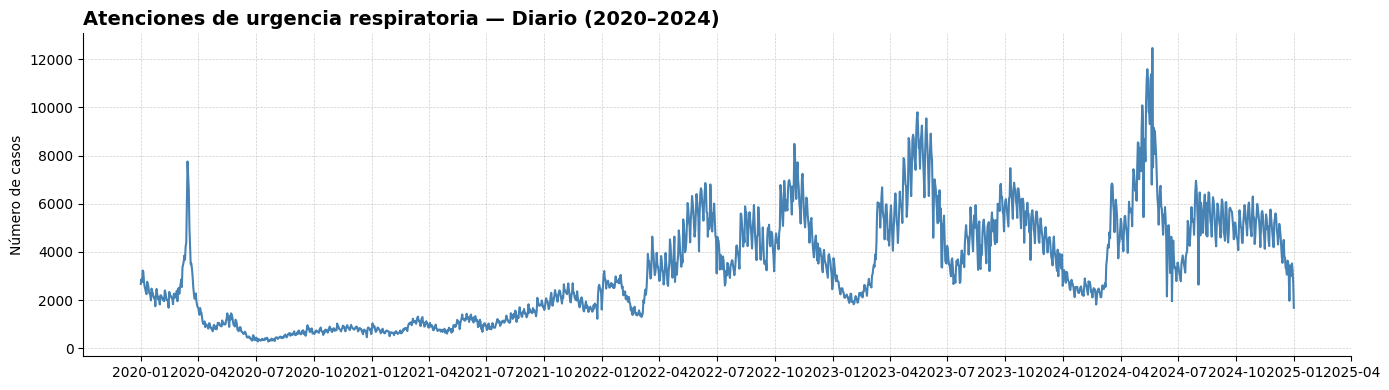

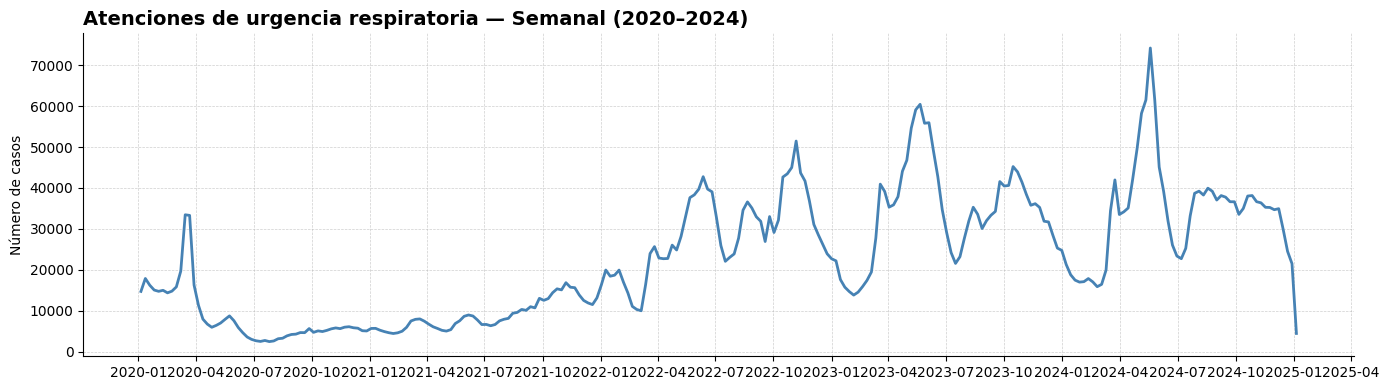

In [3]:
## P1.1 — Series de tiempo diaria (total respiratorio, 2020–2024)
ts_daily = (
    data[data["GlosaCausa"] == RESP_TOTAL]
    .groupby("fecha_dt")["Total"]
    .sum()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts_daily.index, ts_daily.values, linewidth=1.5, color="steelblue")
ax.set_title("Atenciones de urgencia respiratoria — Diario (2020–2024)", fontsize=14, fontweight="bold", loc="left")
ax.set_ylabel("Número de casos")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## P1.2 — Series semanal
ts_weekly = (
    data[data["GlosaCausa"] == RESP_TOTAL]
    .groupby(pd.Grouper(key="fecha_dt", freq="W"))["Total"]
    .sum()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts_weekly.index, ts_weekly.values, linewidth=2, color="steelblue")
ax.set_title("Atenciones de urgencia respiratoria — Semanal (2020–2024)", fontsize=14, fontweight="bold", loc="left")
ax.set_ylabel("Número de casos")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

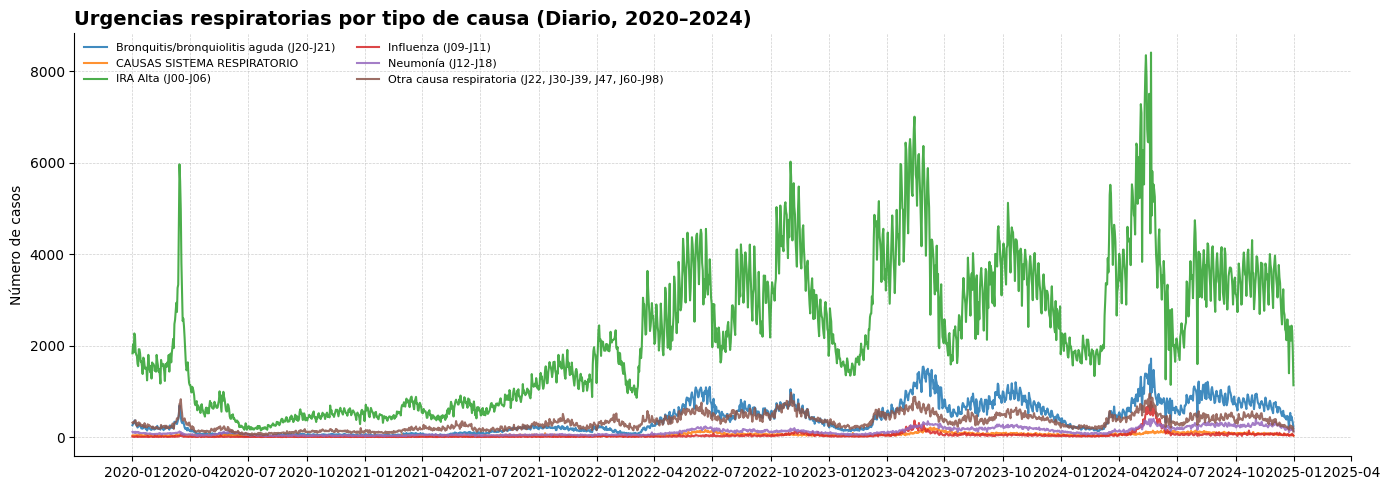

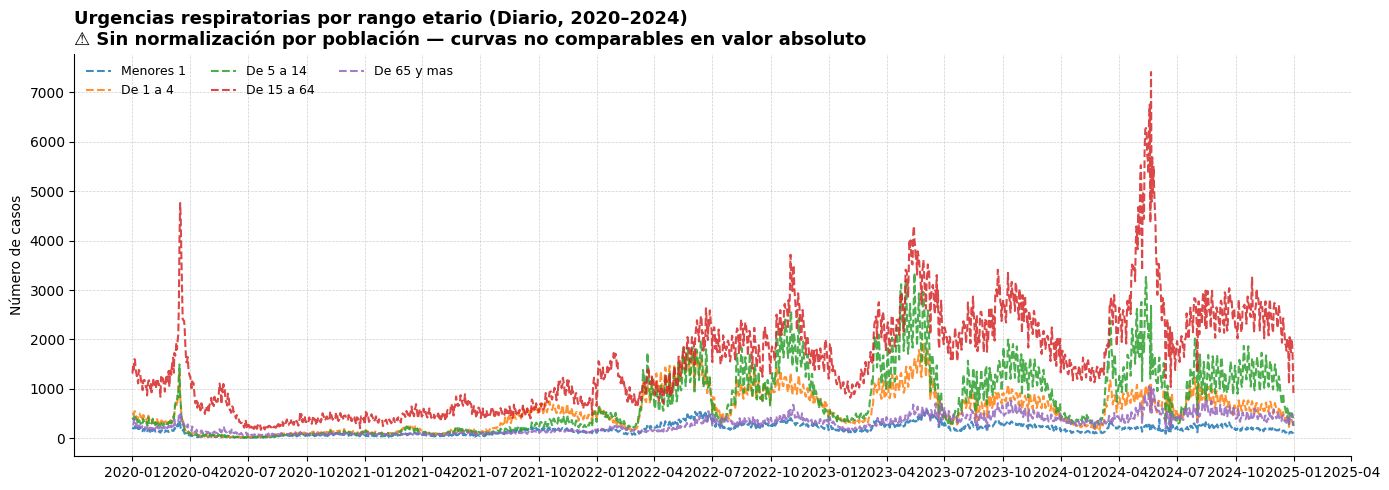

In [4]:
## P1.3 — Desagregación por tipo de causa respiratoria
ts_causa = (
    data[data["GlosaCausa"] != RESP_TOTAL]
    .groupby(["GlosaCausa", "fecha_dt"])["Total"]
    .sum()
    .reset_index()
    .sort_values("fecha_dt")
)

fig, ax = plt.subplots(figsize=(14, 5))
for causa, df_c in ts_causa.groupby("GlosaCausa"):
    ax.plot(df_c["fecha_dt"], df_c["Total"], linewidth=1.5, alpha=0.85, label=causa)
ax.set_title("Urgencias respiratorias por tipo de causa (Diario, 2020–2024)", fontsize=14, fontweight="bold", loc="left")
ax.set_ylabel("Número de casos")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## P1.4 — Desagregación por rango etario
age_cols = ["Menores_1", "De_1_a_4", "De_5_a_14", "De_15_a_64", "De_65_y_mas"]
ts_edad = (
    data[data["GlosaCausa"] == RESP_TOTAL]
    .groupby("fecha_dt")[age_cols]
    .sum()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for col in age_cols:
    ax.plot(ts_edad.index, ts_edad[col], linewidth=1.5, alpha=0.85, linestyle="--", label=col.replace("_", " "))
ax.set_title("Urgencias respiratorias por rango etario (Diario, 2020–2024)\n⚠ Sin normalización por población — curvas no comparables en valor absoluto",
             fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Número de casos")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

Contaminante | SW stat    | SW p-val     | KS stat    | KS p-val     | Veredicto
---------------------------------------------------------------------------
MPM10    | 0.873125   | 2.6713e-53     | 0.110423   | 0.0000e+00     | No normal ✗
MPM25    | 0.756985   | 2.5190e-65     | 0.172498   | 0.0000e+00     | No normal ✗
NO2      | 0.916622   | 3.3561e-46     | 0.107094   | 0.0000e+00     | No normal ✗
O3       | 0.713859   | 1.5158e-68     | 0.250878   | 0.0000e+00     | No normal ✗
SO2      | 0.842140   | 3.3422e-57     | 0.144599   | 0.0000e+00     | No normal ✗


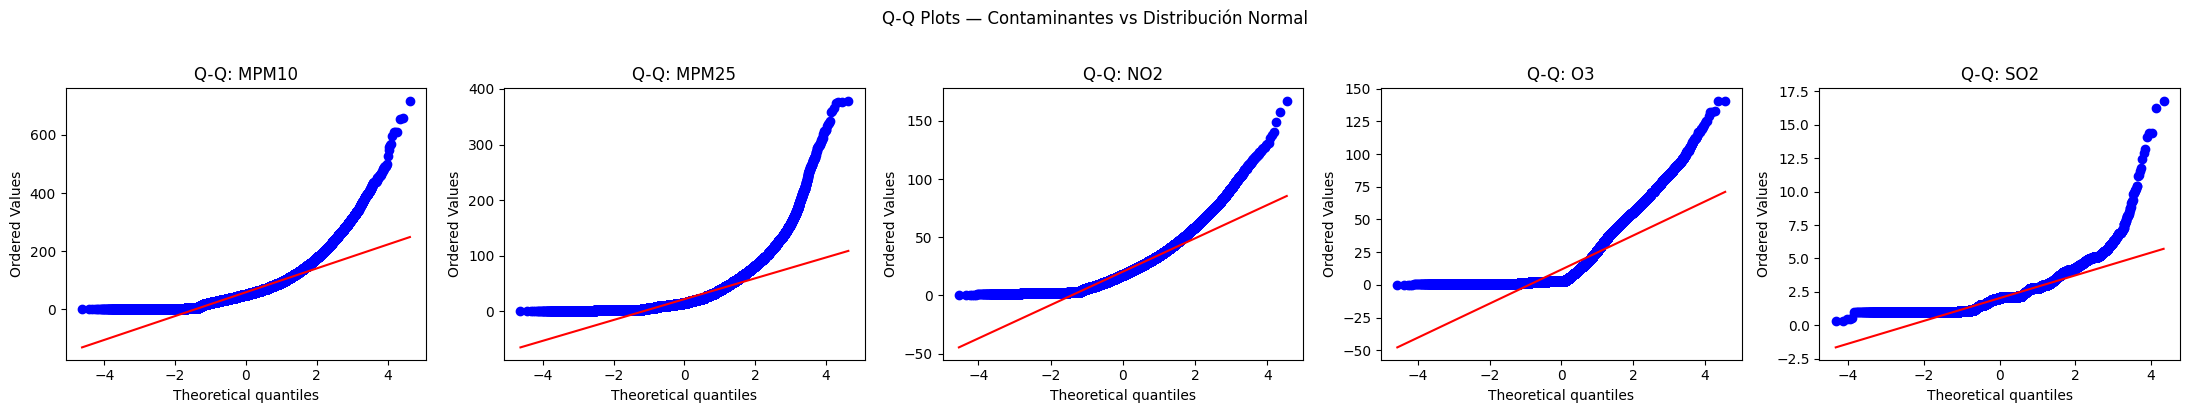

In [5]:
## P1.5 — Test de normalidad (justifica uso de estadísticos no paramétricos)
print(f"{'Contaminante':8} | {'SW stat':10} | {'SW p-val':12} | {'KS stat':10} | {'KS p-val':12} | Veredicto")
print("-" * 75)

normality_results = {}
for pol in POLLUTANTS:
    vals = df_air[pol].dropna()
    sample = vals.sample(min(5000, len(vals)), random_state=42)
    sw_stat, sw_p = shapiro(sample)
    ks_stat, ks_p = kstest((vals - vals.mean()) / vals.std(), "norm")
    normal = sw_p > 0.05 and ks_p > 0.05
    normality_results[pol] = {"sw_p": sw_p, "ks_p": ks_p, "normal": normal}
    verdict = "Normal" if normal else "No normal ✗"
    print(f"{pol.upper():8} | {sw_stat:.6f}   | {sw_p:.4e}     | {ks_stat:.6f}   | {ks_p:.4e}     | {verdict}")

fig, axes = plt.subplots(1, len(POLLUTANTS), figsize=(22, 4))
for ax, pol in zip(axes, POLLUTANTS):
    probplot(df_air[pol].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q: {pol.upper()}")
    ax.lines[-1].set_color("red")  # reference line is always the last line added by probplot
plt.suptitle("Q-Q Plots — Contaminantes vs Distribución Normal", y=1.02)
plt.tight_layout(); plt.show()

=== Kruskal-Wallis: contaminante ~ estación ===
  MPM10   H = 26620.24   p = 0.0000e+00   SIGNIFICATIVO ***
  MPM25   H = 54357.81   p = 0.0000e+00   SIGNIFICATIVO ***
  NO2     H = 45717.65   p = 0.0000e+00   SIGNIFICATIVO ***


  O3      H = 33746.38   p = 0.0000e+00   SIGNIFICATIVO ***
  SO2     H =  3540.17   p = 0.0000e+00   SIGNIFICATIVO ***


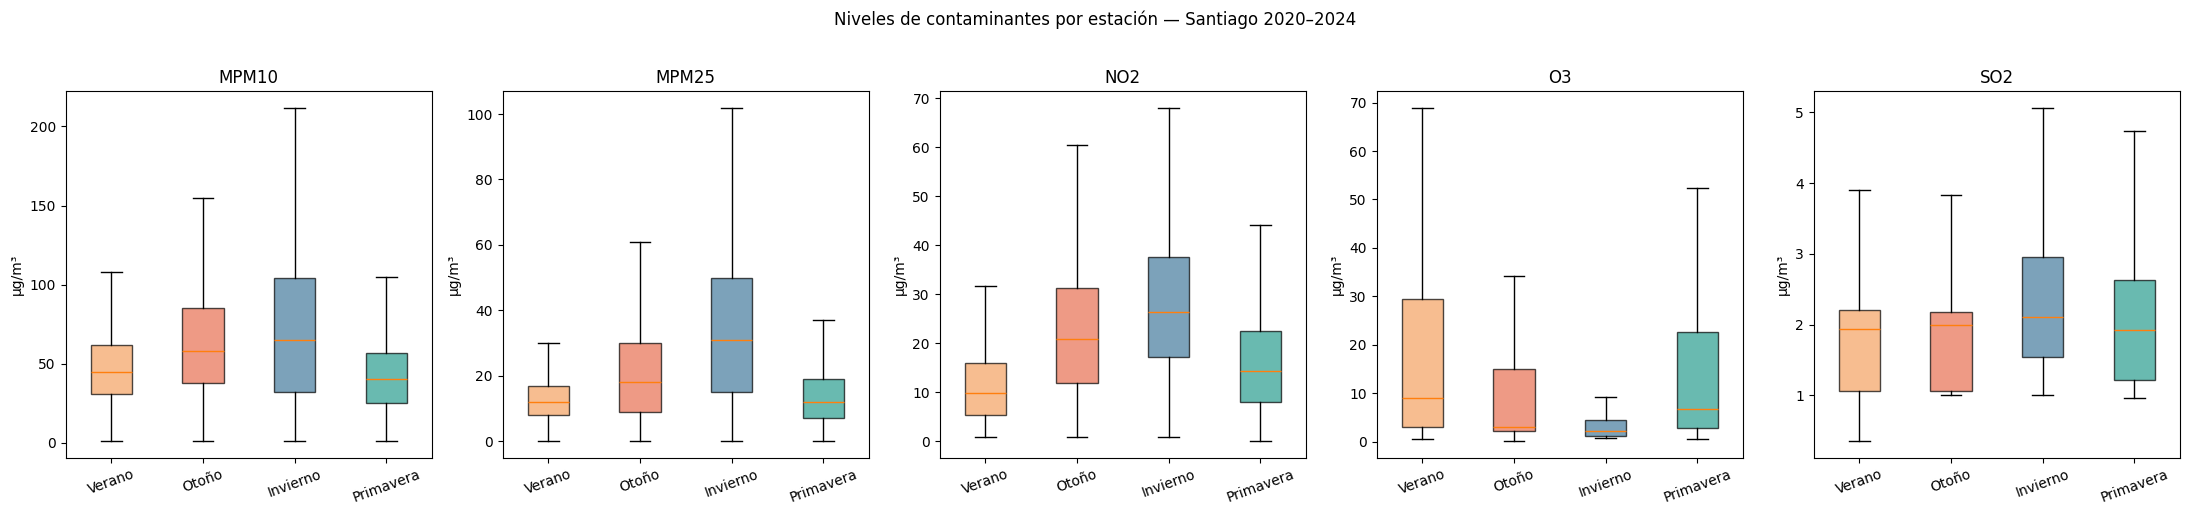


Kruskal-Wallis urgencias ~ estación:  H = 110.59,  p = 8.1785e-24


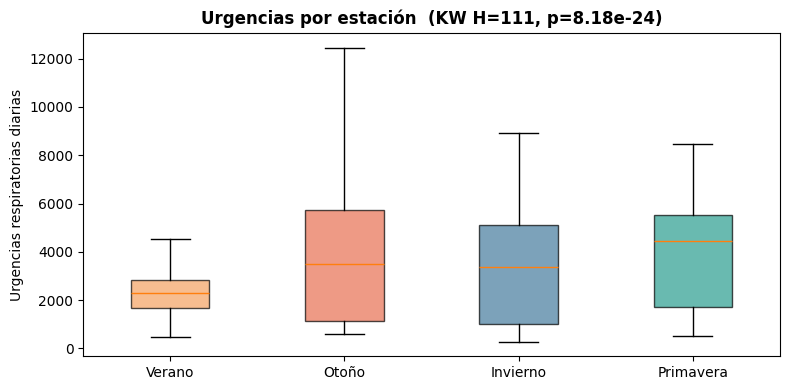

In [6]:
## P1.6 — Kruskal-Wallis: variación estacional de contaminantes y urgencias
df_kw = df_air.copy()
df_kw["season"] = df_kw["time"].dt.month.map({
    12: "Verano", 1: "Verano",  2: "Verano",
     3: "Otoño",  4: "Otoño",   5: "Otoño",
     6: "Invierno", 7: "Invierno", 8: "Invierno",
     9: "Primavera", 10: "Primavera", 11: "Primavera"
})
season_order = ["Verano", "Otoño", "Invierno", "Primavera"]
season_colors = ["#f4a261", "#e76f51", "#457b9d", "#2a9d8f"]

print("=== Kruskal-Wallis: contaminante ~ estación ===")
for pol in POLLUTANTS:
    groups = [g[pol].dropna().values for _, g in df_kw.groupby("season") if g[pol].notna().any()]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        sig = "SIGNIFICATIVO ***" if p < 0.05 else "no significativo"
        print(f"  {pol.upper():6}  H = {stat:8.2f}   p = {p:.4e}   {sig}")

fig, axes = plt.subplots(1, len(POLLUTANTS), figsize=(22, 5))
for ax, pol in zip(axes, POLLUTANTS):
    d = [df_kw[df_kw["season"] == s][pol].dropna() for s in season_order]
    bp = ax.boxplot(d, tick_labels=season_order, showfliers=False, patch_artist=True)
    for patch, color in zip(bp["boxes"], season_colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(pol.upper()); ax.set_ylabel("µg/m³"); ax.tick_params(axis="x", rotation=20)
plt.suptitle("Niveles de contaminantes por estación — Santiago 2020–2024", y=1.02)
plt.tight_layout(); plt.show()

# Kruskal-Wallis para urgencias semanales por estación
resp_kw = df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == RESP_TOTAL].copy()
resp_kw["fecha_dt"] = pd.to_datetime(resp_kw["fecha"], dayfirst=True)
resp_kw["season"] = resp_kw["fecha_dt"].dt.month.map({
    12: "Verano", 1: "Verano", 2: "Verano",
    3: "Otoño", 4: "Otoño", 5: "Otoño",
    6: "Invierno", 7: "Invierno", 8: "Invierno",
    9: "Primavera", 10: "Primavera", 11: "Primavera"
})
resp_kw_weekly = resp_kw.groupby(["fecha_dt", "season"])["Total"].sum().reset_index()

groups_resp = [resp_kw_weekly[resp_kw_weekly["season"] == s]["Total"] for s in season_order]
stat_r, p_r = kruskal(*groups_resp)
print(f"\nKruskal-Wallis urgencias ~ estación:  H = {stat_r:.2f},  p = {p_r:.4e}")

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot([resp_kw_weekly[resp_kw_weekly["season"] == s]["Total"] for s in season_order],
                tick_labels=season_order, showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], season_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel("Urgencias respiratorias diarias")
ax.set_title(f"Urgencias por estación  (KW H={stat_r:.0f}, p={p_r:.2e})", fontweight="bold")
plt.tight_layout(); plt.show()

Semanas alineadas: 261

Contaminante | Spearman r   | p-valor      | Interpretación
------------------------------------------------------------
MPM10    | +0.1119       | 7.1045e-02     | n.s.
MPM25    | +0.0749       | 2.2764e-01     | n.s.
NO2      | +0.2681       | 1.1295e-05     | ***
O3       | +0.0227       | 7.1495e-01     | n.s.
SO2      | +0.1576       | 1.0787e-02     | *


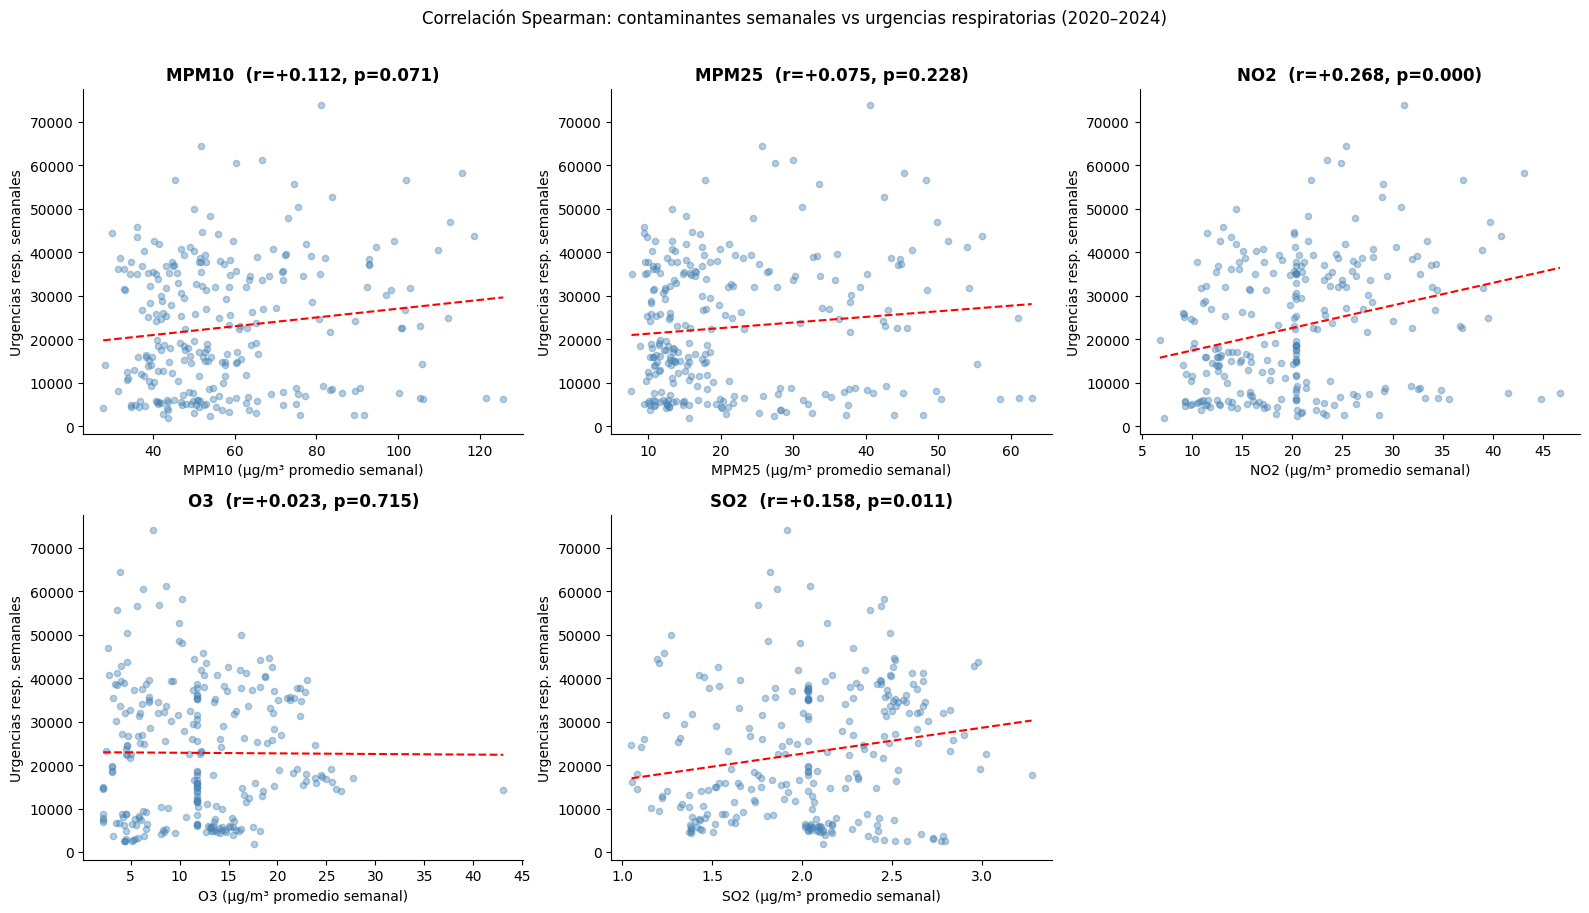

In [7]:
## P1.7 — Correlación Spearman: cada contaminante vs urgencias semanales
# Construir series semanales alineadas
air_w = df_air.copy()
air_w["year"] = air_w["time"].dt.year
air_w["week"] = air_w["time"].dt.isocalendar().week.astype(int)
air_weekly = air_w.groupby(["year", "week"])[POLLUTANTS].mean()

resp_w = df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == RESP_TOTAL].copy()
resp_w["year"] = pd.to_datetime(resp_w["fecha"], dayfirst=True).dt.year
resp_weekly = resp_w.groupby(["year", "semana"])["Total"].sum()
resp_weekly.index.names = ["year", "week"]

p1_df = air_weekly.join(resp_weekly.rename("resp"), how="inner").dropna(subset=["resp"])
p1_df[POLLUTANTS] = p1_df[POLLUTANTS].fillna(p1_df[POLLUTANTS].mean())

print(f"Semanas alineadas: {len(p1_df)}")
print(f"\n{'Contaminante':8} | {'Spearman r':12} | {'p-valor':12} | Interpretación")
print("-" * 60)
assoc_results = {}
for pol in POLLUTANTS:
    r, p = spearmanr(p1_df[pol], p1_df["resp"])
    assoc_results[pol] = (r, p)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"{pol.upper():8} | {r:+.4f}       | {p:.4e}     | {sig}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, pol in enumerate(POLLUTANTS):
    ax = axes[i]
    ax.scatter(p1_df[pol], p1_df["resp"], alpha=0.4, s=20, color="steelblue")
    m, b = np.polyfit(p1_df[pol].fillna(0), p1_df["resp"], 1)
    xl = np.linspace(p1_df[pol].min(), p1_df[pol].max(), 100)
    ax.plot(xl, m * xl + b, "r--", linewidth=1.5)
    r, p = assoc_results[pol]
    ax.set_title(f"{pol.upper()}  (r={r:+.3f}, p={p:.3f})", fontweight="bold")
    ax.set_xlabel(f"{pol.upper()} (µg/m³ promedio semanal)")
    ax.set_ylabel("Urgencias resp. semanales")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
axes[-1].set_visible(False)
plt.suptitle("Correlación Spearman: contaminantes semanales vs urgencias respiratorias (2020–2024)", y=1.01)
plt.tight_layout(); plt.show()

---

## 5. P2 — Impacto Relativo y Efectos No Lineales

**Pregunta:** ¿Qué contaminantes presentan el mayor impacto relativo sobre las atenciones respiratorias, considerando efectos no lineales y posibles interacciones entre contaminantes?

### 5.1 Estrategia

- Categorías de riesgo OMS (PM10, PM2.5) → distribución de niveles de exposición
- **Mutual Information** sobre urgencias semanales → ranking no lineal de relevancia
- Correlación Spearman entre contaminantes → estructura de multicolinealidad
- **PCA** sobre perfiles medios por estación → sistemas independientes de contaminación

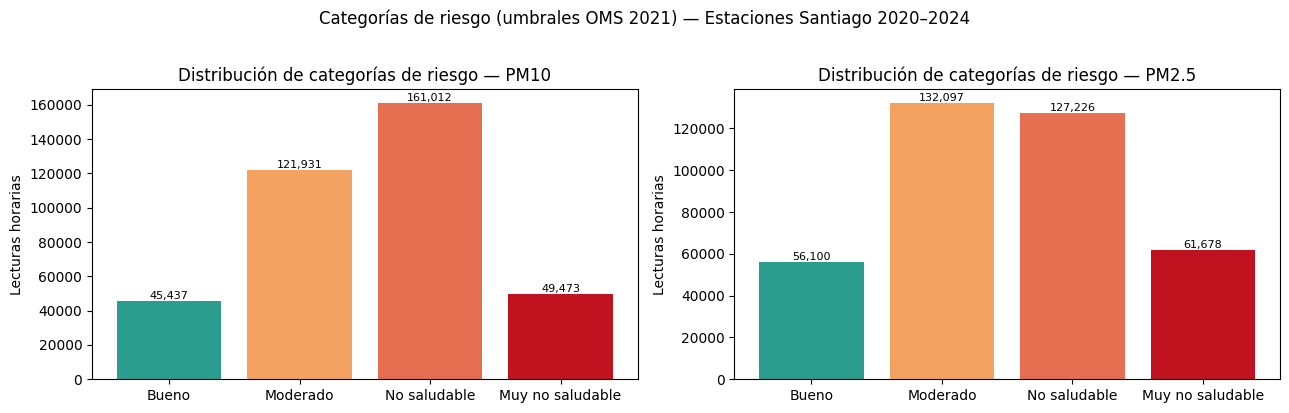

Conteo PM10:


,n
mpm10_cat,
Bueno,45437
Moderado,121931
No saludable,161012
Muy no saludable,49473



Conteo PM2.5:


,n
mpm25_cat,
Bueno,56100
Moderado,132097
No saludable,127226
Muy no saludable,61678


In [8]:
## P2.1 — Distribución de categorías de riesgo PM10 y PM2.5
risk_labels = ["Bueno", "Moderado", "No saludable", "Muy no saludable"]
risk_colors = ["#2a9d8f", "#f4a261", "#e76f51", "#c1121f"]

df_air_binned = df_air.copy()
df_air_binned["mpm10_cat"] = pd.cut(df_air["mpm10"], bins=[0, 15, 45, 100, float("inf")], labels=risk_labels)
df_air_binned["mpm25_cat"] = pd.cut(df_air["mpm25"], bins=[0, 5, 15, 37.5, float("inf")], labels=risk_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes, ["mpm10_cat", "mpm25_cat"], ["PM10", "PM2.5"]):
    counts = df_air_binned[col].value_counts().reindex(risk_labels)
    bars = ax.bar(counts.index, counts.values, color=risk_colors)
    ax.set_title(f"Distribución de categorías de riesgo — {title}")
    ax.set_ylabel("Lecturas horarias")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                f"{val:,}", ha="center", va="bottom", fontsize=8)
plt.suptitle("Categorías de riesgo (umbrales OMS 2021) — Estaciones Santiago 2020–2024", y=1.02)
plt.tight_layout(); plt.show()

print("Conteo PM10:")
display(df_air_binned["mpm10_cat"].value_counts().reindex(risk_labels).to_frame("n"))
print("\nConteo PM2.5:")
display(df_air_binned["mpm25_cat"].value_counts().reindex(risk_labels).to_frame("n"))

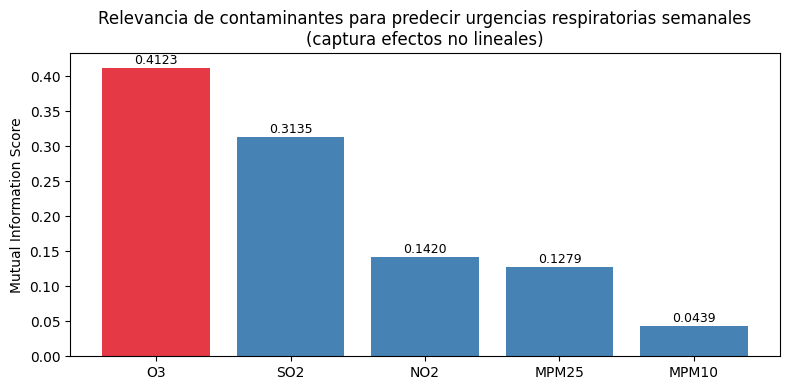

Ranking MI:


,MI Score
o3,0.4123
so2,0.3135
no2,0.1420
mpm25,0.1279
mpm10,0.0439


In [9]:
## P2.2 — Mutual Information: ranking de contaminantes como predictores de urgencias
mi_scores = mutual_info_regression(
    p1_df[POLLUTANTS].fillna(p1_df[POLLUTANTS].mean()),
    p1_df["resp"],
    random_state=42
)
mi_series = pd.Series(mi_scores, index=POLLUTANTS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [p.upper() for p in mi_series.index], mi_series.values,
    color=["#e63946" if v == mi_series.max() else "steelblue" for v in mi_series.values]
)
ax.set_ylabel("Mutual Information Score")
ax.set_title("Relevancia de contaminantes para predecir urgencias respiratorias semanales\n(captura efectos no lineales)")
for bar, val in zip(bars, mi_series.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

print("Ranking MI:")
display(mi_series.to_frame("MI Score").round(4))

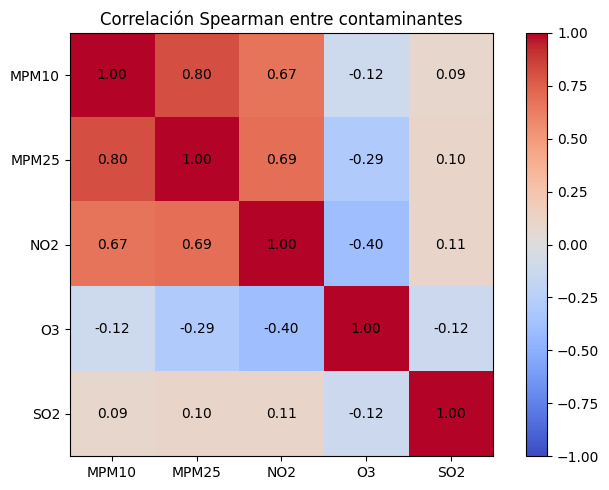

Matriz Spearman r:


,mpm10,mpm25,no2,o3,so2
mpm10,1.000,0.805,0.667,-0.116,0.089
mpm25,0.805,1.000,0.691,-0.290,0.105
no2,0.667,0.691,1.000,-0.396,0.107
o3,-0.116,-0.290,-0.396,1.000,-0.119
so2,0.089,0.105,0.107,-0.119,1.000



Nota: con n > 90,000 todos los p-valores tienen underflow a 0.0 — interpretar directamente los valores r.


In [10]:
## P2.3 — Correlaciones Spearman entre contaminantes (estructura de multicolinealidad)
spearman_r = df_air[POLLUTANTS].corr(method="spearman")
spearman_n = pd.DataFrame(0, index=POLLUTANTS, columns=POLLUTANTS)
for p1 in POLLUTANTS:
    for p2 in POLLUTANTS:
        spearman_n.loc[p1, p2] = int(df_air[[p1, p2]].dropna().shape[0])

labels = [p.upper() for p in POLLUTANTS]
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(spearman_r.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Correlación Spearman entre contaminantes")
plt.colorbar(im, ax=ax)
for i in range(len(POLLUTANTS)):
    for j in range(len(POLLUTANTS)):
        ax.text(j, i, f"{spearman_r.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_xticks(range(len(POLLUTANTS)), labels=labels)
ax.set_yticks(range(len(POLLUTANTS)), labels=labels)
plt.tight_layout(); plt.show()

print("Matriz Spearman r:")
display(spearman_r.round(3))
print("\nNota: con n > 90,000 todos los p-valores tienen underflow a 0.0 — interpretar directamente los valores r.")

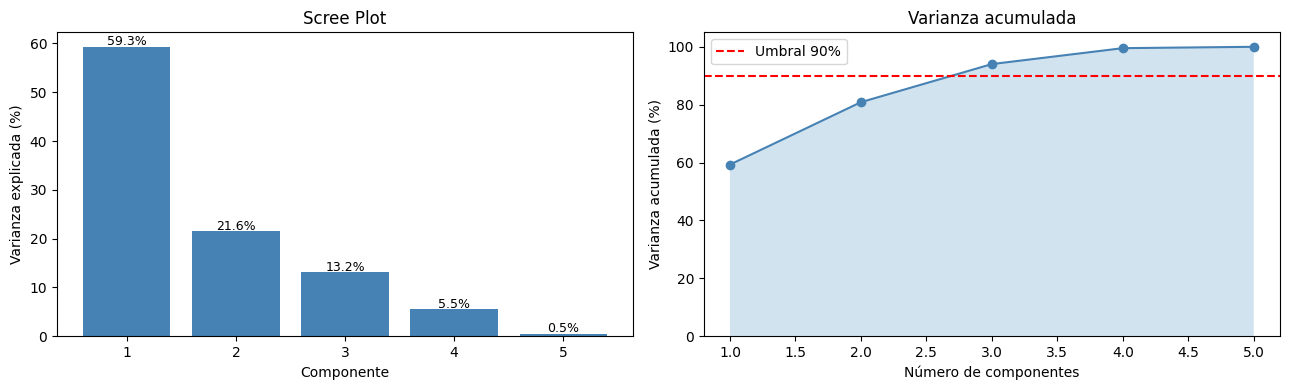

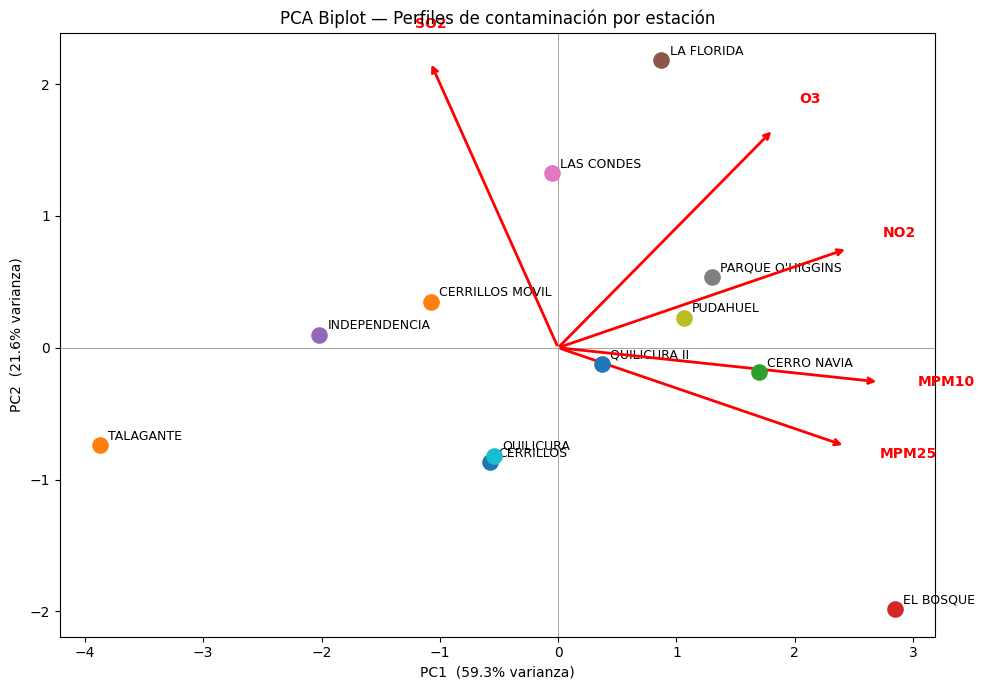

Loadings PCA:


,MPM10,MPM25,NO2,O3,SO2
PC1,0.557,0.498,0.503,0.373,-0.222
PC2,-0.088,-0.254,0.256,0.564,0.738
PC3,0.295,0.486,-0.158,-0.497,0.637
PC4,-0.015,-0.338,0.768,-0.543,0.030
PC5,0.771,-0.581,-0.259,-0.026,0.002


In [11]:
## P2.4 — PCA: sistemas independientes de contaminación por estación
station_profiles = df_air.groupby("nombreEstacion")[POLLUTANTS].mean()
station_profiles_filled = station_profiles.fillna(station_profiles.mean())

scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(station_profiles_filled)
pca = PCA()
scores_pca = pca.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(POLLUTANTS) + 1), pca.explained_variance_ratio_ * 100, color="steelblue")
axes[0].set_xlabel("Componente"); axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Scree Plot")
for i, v in enumerate(pca.explained_variance_ratio_ * 100):
    axes[0].text(i + 1, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(POLLUTANTS) + 1), cum_var, marker="o", color="steelblue")
axes[1].axhline(90, color="red", linestyle="--", label="Umbral 90%")
axes[1].fill_between(range(1, len(POLLUTANTS) + 1), cum_var, alpha=0.2)
axes[1].set_xlabel("Número de componentes"); axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].set_title("Varianza acumulada"); axes[1].set_ylim(0, 105); axes[1].legend()
plt.tight_layout(); plt.show()

# Biplot
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
k = max(abs(scores_pca[:, :2]).max(), 1) / max(abs(loadings[:, :2]).max(), 1) * 0.7

fig, ax = plt.subplots(figsize=(10, 7))
for i, station in enumerate(station_profiles.index):
    ax.scatter(scores_pca[i, 0], scores_pca[i, 1], s=120, zorder=5)
    ax.annotate(station, (scores_pca[i, 0], scores_pca[i, 1]), fontsize=9, xytext=(6, 4), textcoords="offset points")
for j, pol in enumerate(POLLUTANTS):
    lx, ly = loadings[j, 0] * k, loadings[j, 1] * k
    ax.annotate("", xy=(lx, ly), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="red", lw=2))
    ax.text(lx * 1.12, ly * 1.12, pol.upper(), color="red", fontsize=10, fontweight="bold")
ax.axhline(0, color="grey", linewidth=0.5); ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title("PCA Biplot — Perfiles de contaminación por estación")
plt.tight_layout(); plt.show()

print("Loadings PCA:")
display(pd.DataFrame(pca.components_, columns=[p.upper() for p in POLLUTANTS],
                     index=[f"PC{i+1}" for i in range(len(POLLUTANTS))]).round(3))

---

## 6. P3 — Efectos Rezagados

**Pregunta:** ¿Existen efectos rezagados entre la exposición a contaminación atmosférica y los eventos de salud respiratoria, y cuál es la ventana temporal de mayor impacto?

### 6.1 Estrategia

- Correlación cruzada de Spearman entre el contaminante en la semana _t_ y las urgencias en _t_, _t+1_, ..., _t+4_
- Heatmap de r por contaminante × lag y perfil de correlación cruzada
- Identificación del lag óptimo (máximo |r|) por contaminante

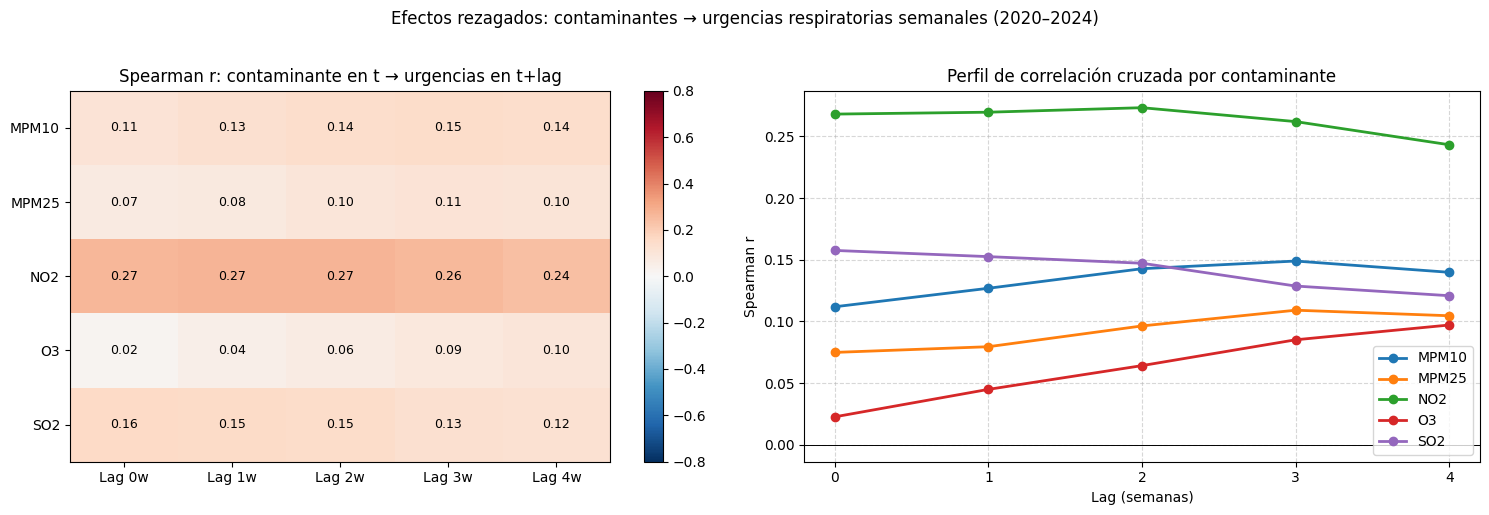

Lag óptimo por contaminante (máximo |r|):


,Contaminante,lag_semanas,spearman_r,p_valor
0,NO2,2,0.273267,0.000008
1,SO2,0,0.157581,0.010787
2,MPM10,3,0.148987,0.016627
3,MPM25,3,0.109141,0.080157
4,O3,4,0.097140,0.120338


In [12]:
## P3.1 — Correlación cruzada con lags 0–4 semanas
MAX_LAG = 4

# p1_df ya contiene las series semanales alineadas de contaminantes y urgencias (creado en P1.7)
lag_results = []
for lag in range(MAX_LAG + 1):
    shifted_resp = p1_df["resp"].shift(-lag)  # contaminante en t predice urgencias en t+lag
    for pol in POLLUTANTS:
        valid = p1_df[pol].notna() & shifted_resp.notna()
        r, p = spearmanr(p1_df[pol][valid], shifted_resp[valid])
        lag_results.append({"Contaminante": pol.upper(), "lag_semanas": lag, "spearman_r": r, "p_valor": p})

lag_corr = pd.DataFrame(lag_results)
lag_pivot = lag_corr.pivot(index="Contaminante", columns="lag_semanas", values="spearman_r")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im = axes[0].imshow(lag_pivot.values, cmap="RdBu_r", vmin=-0.8, vmax=0.8, aspect="auto")
axes[0].set_xticks(range(MAX_LAG + 1), labels=[f"Lag {l}w" for l in range(MAX_LAG + 1)])
axes[0].set_yticks(range(len(POLLUTANTS)), labels=list(lag_pivot.index))
axes[0].set_title("Spearman r: contaminante en t → urgencias en t+lag")
plt.colorbar(im, ax=axes[0])
for i in range(len(POLLUTANTS)):
    for j in range(MAX_LAG + 1):
        val = lag_pivot.values[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        axes[0].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

cmap_lines = plt.colormaps["tab10"]
for k, pol in enumerate(POLLUTANTS):
    sub = lag_corr[lag_corr["Contaminante"] == pol.upper()]
    axes[1].plot(sub["lag_semanas"], sub["spearman_r"], marker="o", label=pol.upper(),
                 color=cmap_lines(k), linewidth=2)
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].set_xlabel("Lag (semanas)"); axes[1].set_ylabel("Spearman r")
axes[1].set_title("Perfil de correlación cruzada por contaminante")
axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].set_xticks(range(MAX_LAG + 1))

plt.suptitle("Efectos rezagados: contaminantes → urgencias respiratorias semanales (2020–2024)", y=1.02)
plt.tight_layout(); plt.show()

print("Lag óptimo por contaminante (máximo |r|):")
best_lag = (
    lag_corr.loc[lag_corr.groupby("Contaminante")["spearman_r"]
    .transform(lambda x: abs(x) == abs(x).max())]
    .sort_values("spearman_r", ascending=False)
)
display(best_lag.reset_index(drop=True))

---

## 7. P4 — Patrones Espaciales y Clusters Territoriales

**Pregunta:** ¿Qué patrones espaciales y clusters territoriales de riesgo pueden identificarse en los establecimientos de la Región Metropolitana a partir de variables de contaminación y salud?

### 7.1 Estrategia

- Tasa respiratoria por establecimiento vs PM10 de la estación más cercana (Spearman)
- PCA sobre perfiles normalizados de causa por establecimiento
- **K-means** (k=4) sobre los primeros componentes PCA → clusters funcionales por perfil de enfermedad
- Verificación: ¿los clusters de enfermedad se alinean con diferencias en PM10? (Kruskal-Wallis)

Spearman r (PM10 vs tasa resp): 0.073,  p = 0.395

Tasa respiratoria media por tipo de establecimiento:


,resp_rate,nearest_pm10
TipoEstablecimientoGlosa,,
Centro de Salud Familiar (CESFAM),0.380,62.033
Servicio de Atención Primaria de Urgencia (SAPU),0.278,59.449
Servicio de Urgencia Rural (SUR),0.234,47.840
Servicio de Atención Primaria de Urgencia de Alta Resolutividad (SAR),0.223,58.921
Hospital,0.129,54.651


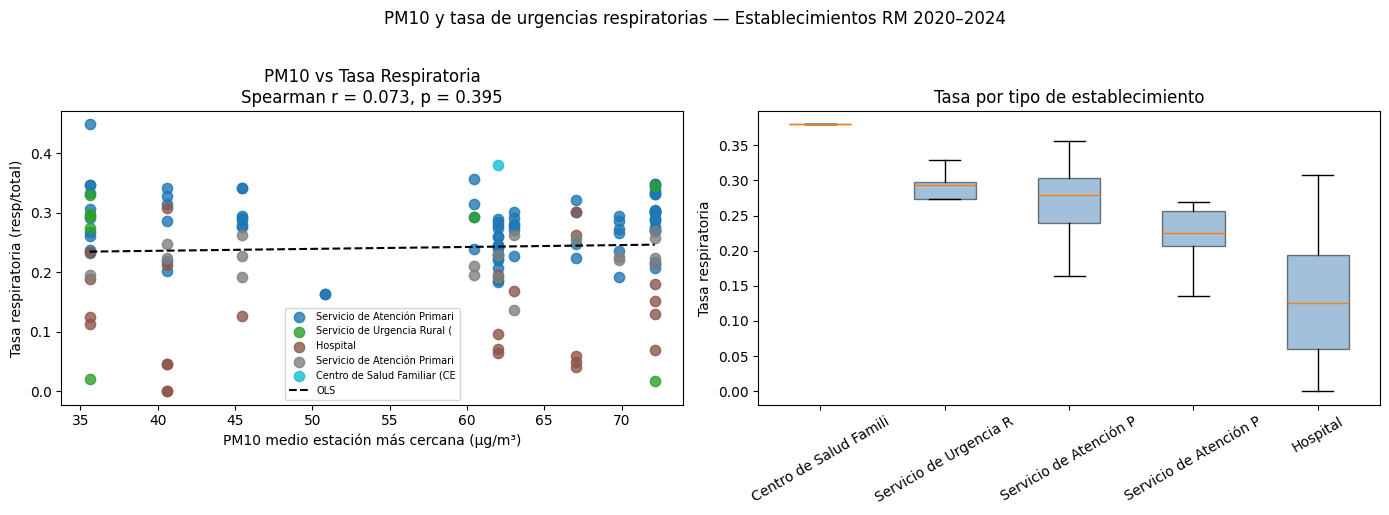

In [13]:
## P4.1 — Análisis espacial: tasa respiratoria por establecimiento vs PM10 más cercano
total_att = (
    df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == "SECCIÓN 1. TOTAL ATENCIONES DE URGENCIA"]
    .assign(id=lambda x: x["IdEstablecimiento"].str.strip())
    .groupby("id")["Total"].sum().reset_index(name="total_att")
)
resp_att = (
    df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == RESP_TOTAL]
    .assign(id=lambda x: x["IdEstablecimiento"].str.strip())
    .groupby("id")["Total"].sum().reset_index(name="resp_att")
)
spatial_rate = (
    df_estab_rm[["id", "EstablecimientoGlosa", "TipoEstablecimientoGlosa",
                  "nearest_station", "nearest_pm10", "dist_km"]]
    .merge(resp_att, on="id", how="inner")
    .merge(total_att, on="id", how="left")
    .dropna(subset=["total_att"])
    .query("total_att > 0")
    .copy()
)
spatial_rate["resp_rate"] = spatial_rate["resp_att"] / spatial_rate["total_att"]
valid_sr = spatial_rate.dropna(subset=["nearest_pm10"]).copy()

r_sr, p_sr = spearmanr(valid_sr["nearest_pm10"], valid_sr["resp_rate"])
print(f"Spearman r (PM10 vs tasa resp): {r_sr:.3f},  p = {p_sr:.3f}")
print("\nTasa respiratoria media por tipo de establecimiento:")
display(valid_sr.groupby("TipoEstablecimientoGlosa")[["resp_rate", "nearest_pm10"]].mean().round(3)
        .sort_values("resp_rate", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap_sr = plt.colormaps["tab10"]
tipos = valid_sr["TipoEstablecimientoGlosa"].unique()
for i, t in enumerate(tipos):
    sub = valid_sr[valid_sr["TipoEstablecimientoGlosa"] == t]
    axes[0].scatter(sub["nearest_pm10"], sub["resp_rate"], label=t[:28], color=cmap_sr(i / max(len(tipos)-1,1)), s=55, alpha=0.8)
m, b = np.polyfit(valid_sr["nearest_pm10"], valid_sr["resp_rate"], 1)
xl = np.linspace(valid_sr["nearest_pm10"].min(), valid_sr["nearest_pm10"].max(), 100)
axes[0].plot(xl, m * xl + b, "k--", linewidth=1.5, label="OLS")
axes[0].set_xlabel("PM10 medio estación más cercana (µg/m³)")
axes[0].set_ylabel("Tasa respiratoria (resp/total)")
axes[0].set_title(f"PM10 vs Tasa Respiratoria\nSpearman r = {r_sr:.3f}, p = {p_sr:.3f}")
axes[0].legend(fontsize=7)

tipos_ord = spatial_rate.groupby("TipoEstablecimientoGlosa")["resp_rate"].median().sort_values(ascending=False).index
axes[1].boxplot([spatial_rate[spatial_rate["TipoEstablecimientoGlosa"] == t]["resp_rate"] for t in tipos_ord],
                tick_labels=[t[:22] for t in tipos_ord], showfliers=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.5))
axes[1].set_ylabel("Tasa respiratoria"); axes[1].set_title("Tasa por tipo de establecimiento")
axes[1].tick_params(axis="x", rotation=30)
plt.suptitle("PM10 y tasa de urgencias respiratorias — Establecimientos RM 2020–2024", y=1.02)
plt.tight_layout(); plt.show()

Establecimientos: 148  |  Causas hoja: 27
Varianza PC1: 27.9%  PC1+2: 46.5%


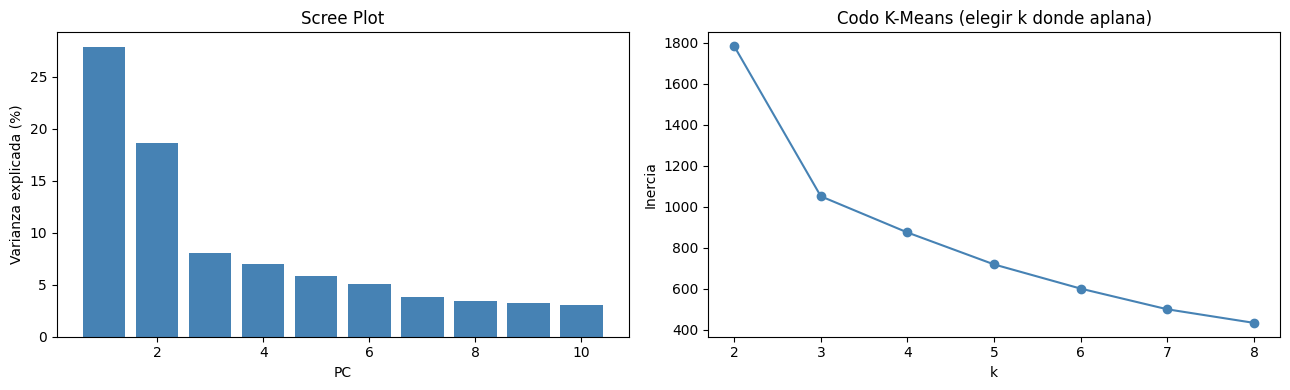

In [14]:
## P4.2 — Clustering K-means sobre perfiles de causa por establecimiento
EXCLUDE_CAUSES = {
    "CAUSAS SISTEMA RESPIRATORIO", "CIRUGÍAS DE URGENCIA",
    "Pacientes en espera de hospitalización",
    "Pacientes en espera de hospitalización que esperan menos de 12 horas "
    "para ser trasladados a cama hospitalaria",
}
leaf_urg = df_urgencia_rm[
    ~df_urgencia_rm["GlosaCausa"].str.startswith(("TOTAL", "SECCIÓN", " -"), na=False) &
    ~df_urgencia_rm["GlosaCausa"].isin(EXCLUDE_CAUSES)
].copy()
leaf_urg["id"] = leaf_urg["IdEstablecimiento"].str.strip()

pivot_raw = leaf_urg.groupby(["id", "GlosaCausa"])["Total"].sum().unstack(fill_value=0)
pivot_raw = pivot_raw[pivot_raw.sum(axis=1) > 0]
pivot_norm = pivot_raw.div(pivot_raw.sum(axis=1), axis=0)
estab_ids = pivot_norm.index.tolist()
cause_names = list(pivot_norm.columns)

id_to_pm10 = df_estab_rm.set_index("id")["nearest_pm10"].to_dict()
id_to_type = df_estab_rm.set_index("id")["TipoEstablecimientoGlosa"].to_dict()
pm10_arr   = np.array([id_to_pm10.get(i, np.nan) for i in estab_ids])
type_arr   = np.array([id_to_type.get(i, "Desconocido") for i in estab_ids])

scaler_cl = StandardScaler()
X_cl_sc   = scaler_cl.fit_transform(pivot_norm.values)
n_comp_cl = min(10, X_cl_sc.shape[0] - 1, X_cl_sc.shape[1])
pca_cl    = PCA(n_components=n_comp_cl)
scores_cl = pca_cl.fit_transform(X_cl_sc)

print(f"Establecimientos: {len(pivot_norm)}  |  Causas hoja: {len(cause_names)}")
print(f"Varianza PC1: {pca_cl.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC1+2: {np.cumsum(pca_cl.explained_variance_ratio_)[1]*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(scores_cl[:, :5]).inertia_ for k in range(2, 9)]
axes[0].bar(range(1, n_comp_cl + 1), pca_cl.explained_variance_ratio_ * 100, color="steelblue")
axes[0].set_xlabel("PC"); axes[0].set_ylabel("Varianza explicada (%)"); axes[0].set_title("Scree Plot")
axes[1].plot(range(2, 9), inertias, "o-", color="steelblue")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Inercia"); axes[1].set_title("Codo K-Means (elegir k donde aplana)")
plt.tight_layout(); plt.show()

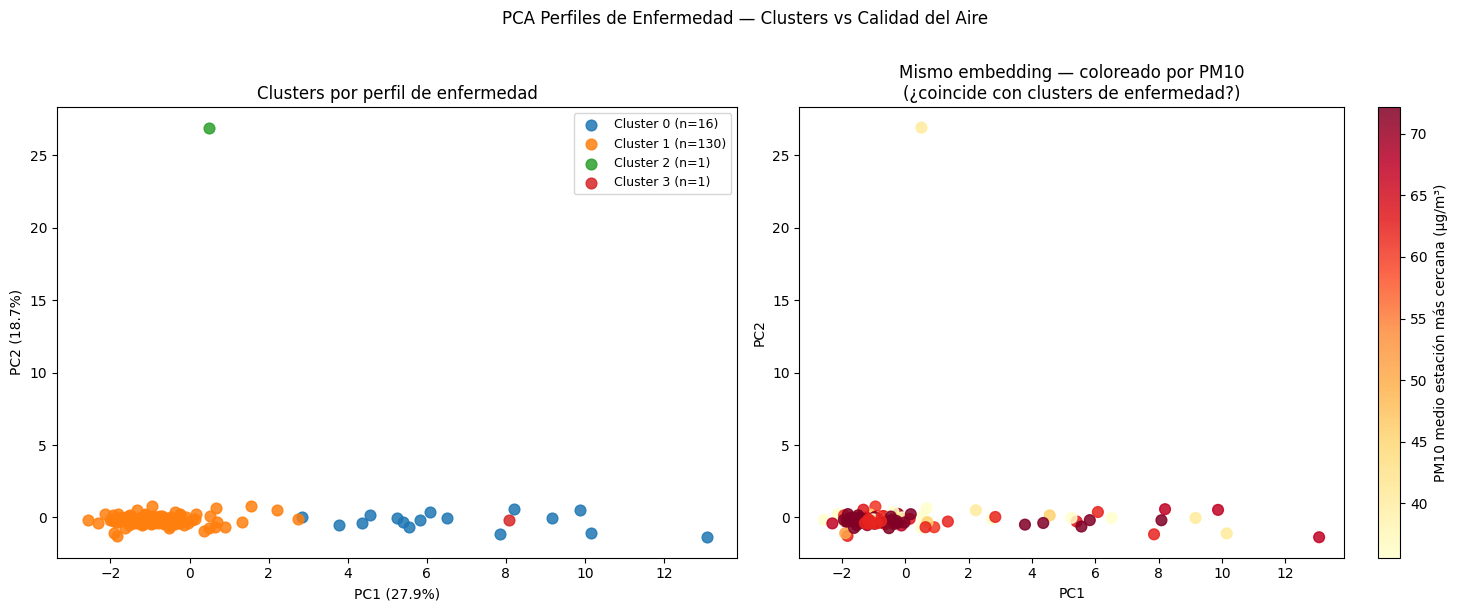

Kruskal-Wallis PM10 entre clusters: H = 2.99, p = 0.3938


,n,mean_pm10,std_pm10
cluster,,,
3,1,72.15,NaN
0,16,58.54,13.86
1,121,57.80,13.58
2,1,40.58,NaN


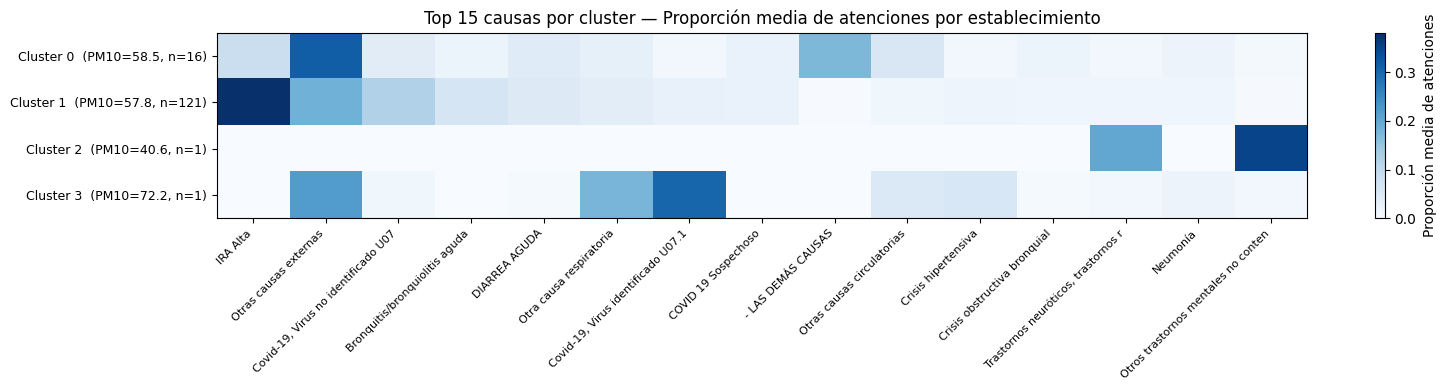

In [15]:
## P4.3 — K-means k=4: biplot, heatmap de causas y correlación por causa vs PM10
N_CLUSTERS = 4
km_cl     = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cl_labels = km_cl.fit_predict(scores_cl[:, :5])
cmap_cl   = plt.colormaps["tab10"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for cl in range(N_CLUSTERS):
    mask = cl_labels == cl
    axes[0].scatter(scores_cl[mask, 0], scores_cl[mask, 1],
                    label=f"Cluster {cl} (n={mask.sum()})", color=cmap_cl(cl), s=60, alpha=0.85)
axes[0].set_xlabel(f"PC1 ({pca_cl.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_cl.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("Clusters por perfil de enfermedad"); axes[0].legend(fontsize=9)

sc2 = axes[1].scatter(scores_cl[:, 0], scores_cl[:, 1], c=pm10_arr, cmap="YlOrRd", s=60, alpha=0.85)
plt.colorbar(sc2, ax=axes[1], label="PM10 medio estación más cercana (µg/m³)")
axes[1].set_xlabel(f"PC1"); axes[1].set_ylabel(f"PC2")
axes[1].set_title("Mismo embedding — coloreado por PM10\n(¿coincide con clusters de enfermedad?)")
plt.suptitle("PCA Perfiles de Enfermedad — Clusters vs Calidad del Aire", y=1.01)
plt.tight_layout(); plt.show()

# Kruskal-Wallis: ¿los clusters difieren en PM10?
cl_df = pd.DataFrame({"cluster": cl_labels, "nearest_pm10": pm10_arr, "tipo": type_arr}, index=estab_ids)
cl_summary = cl_df.groupby("cluster").agg(n=("nearest_pm10","count"), mean_pm10=("nearest_pm10","mean"),
                                           std_pm10=("nearest_pm10","std")).round(2)
h_stat, p_kw = kruskal(*[cl_df[cl_df["cluster"] == cl]["nearest_pm10"].dropna() for cl in range(N_CLUSTERS)])
print(f"Kruskal-Wallis PM10 entre clusters: H = {h_stat:.2f}, p = {p_kw:.4f}")
display(cl_summary.sort_values("mean_pm10", ascending=False))

# Heatmap top 15 causas por cluster
pivot_with_cl = pivot_norm.copy(); pivot_with_cl["cluster"] = cl_labels
top15 = pivot_norm.mean().sort_values(ascending=False).head(15).index
cl_top = pivot_with_cl.groupby("cluster").mean()[top15]
short_labels = [c.split("(")[0].strip()[:35] for c in top15]
fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(cl_top.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(top15)), labels=short_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(N_CLUSTERS),
              labels=[f"Cluster {i}  (PM10={cl_summary.loc[i,'mean_pm10']:.1f}, n={int(cl_summary.loc[i,'n'])})"
                      for i in range(N_CLUSTERS)], fontsize=9)
plt.colorbar(im, ax=ax, label="Proporción media de atenciones")
ax.set_title("Top 15 causas por cluster — Proporción media de atenciones por establecimiento")
plt.tight_layout(); plt.show()

---

## 8. P5 — Predicción de Días de Alto Riesgo Sanitario

**Pregunta:** ¿Es posible predecir semanas de alto riesgo sanitario utilizando modelos de aprendizaje automático basados en contaminantes atmosféricos?

### 8.1 Estrategia

- Variable objetivo binaria: semana sobre/bajo la mediana de urgencias respiratorias
- Features: promedios semanales de PM10, PM2.5, NO₂, O₃, SO₂
- Modelos: **Regresión Logística** y **Árbol de Decisión** con GridSearchCV
- Evaluación: F1 macro en validación cruzada 5-fold + conjunto de test (70/30)

In [16]:
## P5.1 — Preparación de datos para clasificación
# p1_df ya tiene las series semanales alineadas (contaminantes + urgencias)
weekly_cls = p1_df.copy()
weekly_cls["alto_riesgo"] = (weekly_cls["resp"] > weekly_cls["resp"].median()).astype(int)

X_cls = weekly_cls[POLLUTANTS]
y_cls = weekly_cls["alto_riesgo"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.3, stratify=y_cls, random_state=42
)
scaler_cls = StandardScaler()
X_train_sc = scaler_cls.fit_transform(X_train)
X_test_sc  = scaler_cls.transform(X_test)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Total semanas  : {len(weekly_cls)}")
print(f"Train / Test   : {len(X_train)} / {len(X_test)}")
print(f"Balance clases : {y_cls.value_counts().to_dict()}  (0=Bajo, 1=Alto)")
display(weekly_cls.head(6))

Total semanas  : 261
Train / Test   : 182 / 79
Balance clases : {0: 131, 1: 130}  (0=Bajo, 1=Alto)


mpm10      mpm25        no2         o3       so2   resp  \
year week                                                                
2020 1     51.197143  15.995126  20.361517  11.763893  1.741291  11527   
     2     47.617834  12.836369  20.361517  11.763893  1.733749  18351   
     3     65.657738  16.496190  20.361517  11.763893  1.981947  16548   
     4     52.629226  14.374107  20.361517  11.763893  1.769188  14934   
     5     53.401964  13.736488  13.853090  11.763893  1.517684  14992   
     6     43.815952  11.235000  14.810985   2.200000  1.519699  14849   

           alto_riesgo  
year week               
2020 1               0  
     2               0  
     3               0  
     4               0  
     5               0  
     6               0

=== Regresión Logística — Test Set ===
              precision    recall  f1-score   support

        Bajo       0.59      0.65      0.62        40
        Alto       0.60      0.54      0.57        39

    accuracy                           0.59        79
   macro avg       0.60      0.59      0.59        79
weighted avg       0.60      0.59      0.59        79

CV F1 macro (5-fold): 0.712 ± 0.039


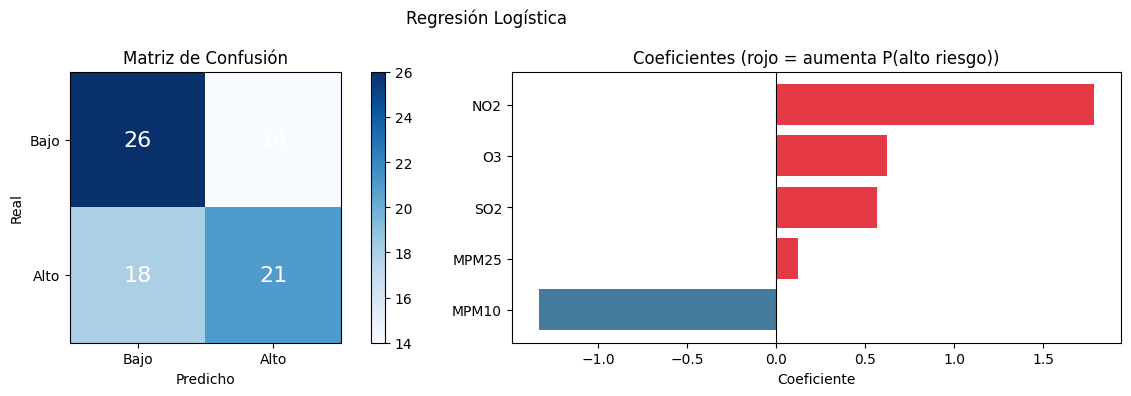

In [17]:
## P5.2 — Regresión Logística
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("=== Regresión Logística — Test Set ===")
print(classification_report(y_test, y_pred_lr, target_names=["Bajo", "Alto"]))
cv_lr = cross_val_score(lr, scaler_cls.fit_transform(X_cls), y_cls, cv=cv5, scoring="f1_macro")
print(f"CV F1 macro (5-fold): {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
im = axes[0].imshow(cm_lr, cmap="Blues")
axes[0].set_xticks([0, 1], labels=["Bajo", "Alto"])
axes[0].set_yticks([0, 1], labels=["Bajo", "Alto"])
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real"); axes[0].set_title("Matriz de Confusión")
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_lr[i,j], ha="center", va="center", fontsize=16,
                     color="white" if cm_lr[i,j] > cm_lr.max()/2 else "black")

coef = pd.Series(lr.coef_[0], index=[p.upper() for p in POLLUTANTS]).sort_values()
axes[1].barh(coef.index, coef.values, color=["#e63946" if v > 0 else "#457b9d" for v in coef.values])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Coeficientes (rojo = aumenta P(alto riesgo))"); axes[1].set_xlabel("Coeficiente")
plt.suptitle("Regresión Logística"); plt.tight_layout(); plt.show()

Mejores parámetros : {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 6}
Mejor CV F1        : 0.703

=== Árbol de Decisión (mejores params) — Test Set ===
              precision    recall  f1-score   support

        Bajo       0.65      0.65      0.65        40
        Alto       0.64      0.64      0.64        39

    accuracy                           0.65        79
   macro avg       0.65      0.65      0.65        79
weighted avg       0.65      0.65      0.65        79

CV F1 macro (5-fold): 0.703 ± 0.062


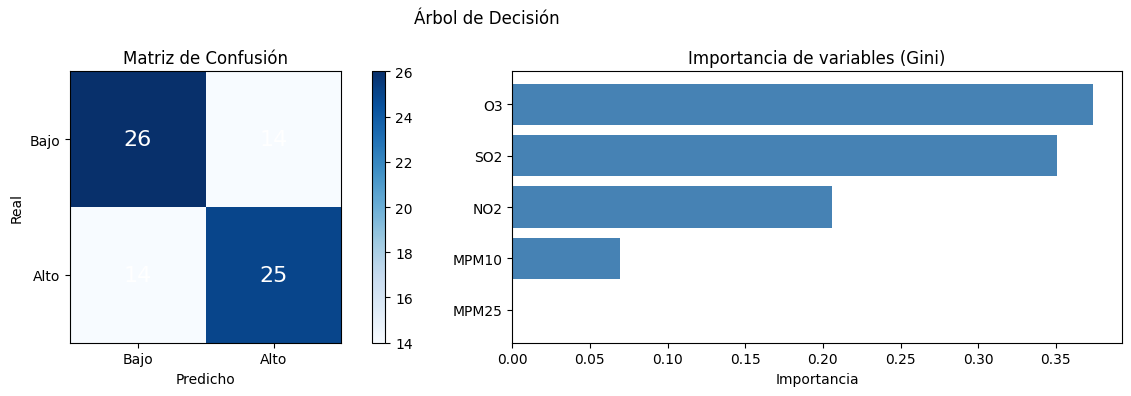

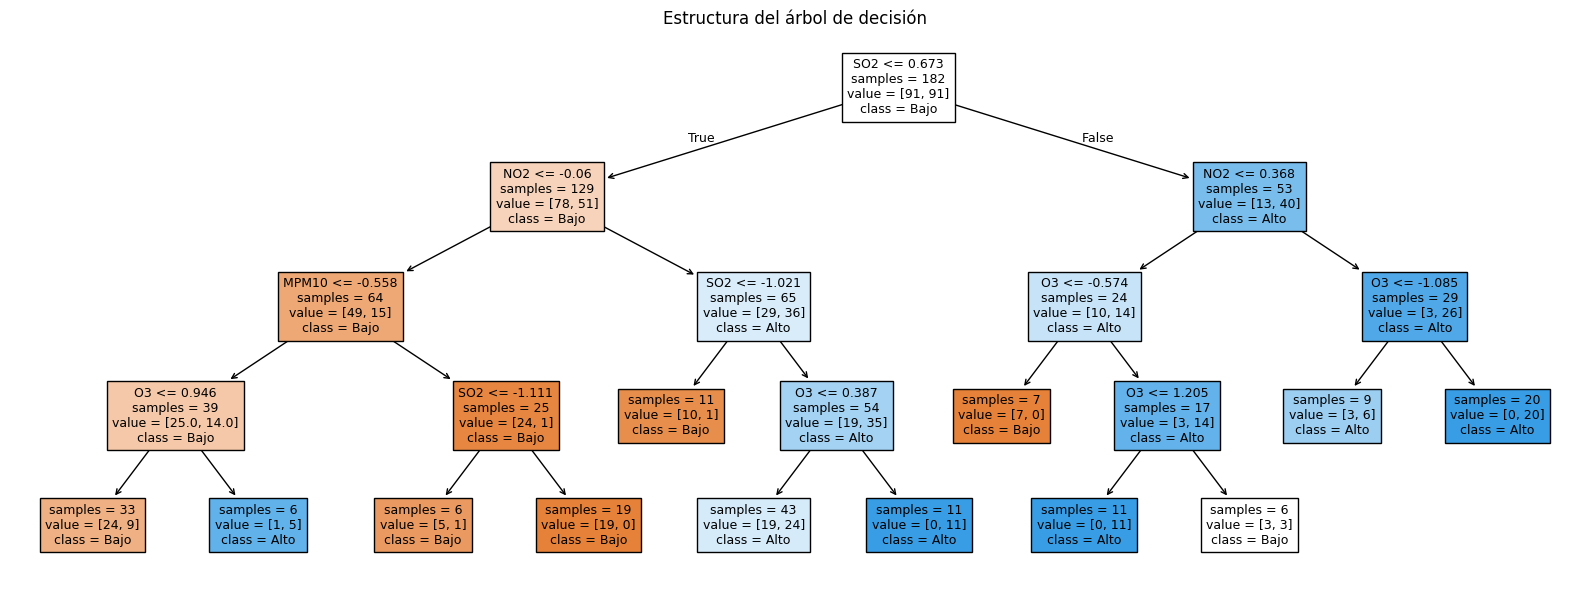

In [18]:
## P5.3 — Árbol de Decisión con GridSearchCV
param_grid = {"criterion": ["gini","entropy"], "max_depth": [2,3,4,5,None], "min_samples_leaf": [2,4,6]}
gs = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="f1_macro", n_jobs=-1
)
gs.fit(X_cls, y_cls)
print(f"Mejores parámetros : {gs.best_params_}")
print(f"Mejor CV F1        : {gs.best_score_:.3f}")

best_dt = gs.best_estimator_
best_dt.fit(X_train_sc, y_train)
y_pred_dt = best_dt.predict(X_test_sc)
print("\n=== Árbol de Decisión (mejores params) — Test Set ===")
print(classification_report(y_test, y_pred_dt, target_names=["Bajo","Alto"]))
cv_dt = cross_val_score(best_dt, scaler_cls.fit_transform(X_cls), y_cls, cv=cv5, scoring="f1_macro")
print(f"CV F1 macro (5-fold): {cv_dt.mean():.3f} ± {cv_dt.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
im = axes[0].imshow(cm_dt, cmap="Blues")
axes[0].set_xticks([0, 1], labels=["Bajo", "Alto"])
axes[0].set_yticks([0, 1], labels=["Bajo", "Alto"])
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real"); axes[0].set_title("Matriz de Confusión")
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_dt[i,j], ha="center", va="center", fontsize=16,
                     color="white" if cm_dt[i,j] > cm_dt.max()/2 else "black")
imp = pd.Series(best_dt.feature_importances_, index=[p.upper() for p in POLLUTANTS]).sort_values()
axes[1].barh(imp.index, imp.values, color="steelblue")
axes[1].set_title("Importancia de variables (Gini)"); axes[1].set_xlabel("Importancia")
plt.suptitle("Árbol de Decisión"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(best_dt, feature_names=[p.upper() for p in POLLUTANTS],
          class_names=["Bajo","Alto"], filled=True, ax=ax, fontsize=9, impurity=False)
ax.set_title("Estructura del árbol de decisión")
plt.tight_layout(); plt.show()

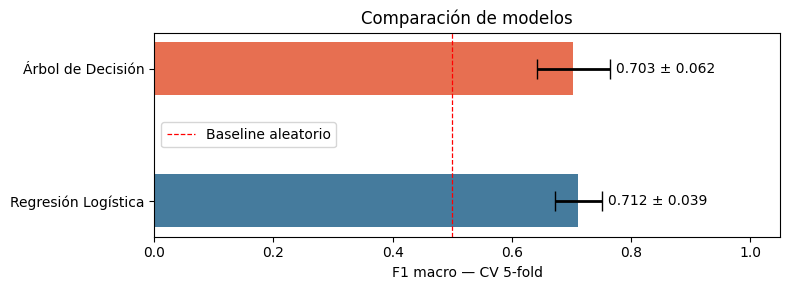

Detalle por fold:
  Regresión Logística: [0.736  0.711  0.768  0.690  0.654]  mean=0.712  std=0.039
  Árbol de Decisión: [0.713  0.711  0.788  0.595  0.711]  mean=0.703  std=0.062


In [19]:
## P5.4 — Comparación de modelos
X_sc_all = scaler_cls.fit_transform(X_cls)
model_scores = {
    "Regresión Logística": cross_val_score(
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
        X_sc_all, y_cls, cv=cv5, scoring="f1_macro"),
    "Árbol de Decisión": cross_val_score(
        gs.best_estimator_, X_sc_all, y_cls, cv=cv5, scoring="f1_macro"),
}

fig, ax = plt.subplots(figsize=(8, 3))
names = list(model_scores.keys())
means = [s.mean() for s in model_scores.values()]
stds  = [s.std()  for s in model_scores.values()]
bars = ax.barh(names, means, xerr=stds, color=["#457b9d","#e76f51"],
               capsize=7, height=0.4, error_kw={"linewidth": 2})
ax.set_xlabel("F1 macro — CV 5-fold"); ax.set_title("Comparación de modelos")
ax.set_xlim(0, 1.05)
ax.axvline(0.5, color="red", linestyle="--", linewidth=0.9, label="Baseline aleatorio")
for bar, m, s in zip(bars, means, stds):
    ax.text(m + s + 0.01, bar.get_y() + bar.get_height()/2,
            f"{m:.3f} ± {s:.3f}", va="center", fontsize=10)
ax.legend(); plt.tight_layout(); plt.show()

print("Detalle por fold:")
for name, scores in model_scores.items():
    fold_str = "  ".join([f"{s:.3f}" for s in scores])
    print(f"  {name}: [{fold_str}]  mean={scores.mean():.3f}  std={scores.std():.3f}")

---

## 9. P6 — Umbrales Normativos y Efectos Causales

**Pregunta:** ¿Se observan cambios significativos en los eventos de salud respiratoria cuando los niveles de contaminación superan ciertos umbrales normativos, sugiriendo posibles efectos causales o discontinuidades?

### 9.1 Estrategia

- Episodios según norma chilena ICA: PM10 > 100 µg/m³, PM2.5 > 37.5 µg/m³
- **DiD:** urgencias en días de episodio vs días normales (Kruskal-Wallis)
- **RDD:** ajuste lineal a cada lado del umbral → estimación del salto en urgencias

| Contaminante | Umbral (Chile ICA — nivel Malo) |
|---|---|
| PM10 | 100 µg/m³ (promedio diario) |
| PM2.5 | 37.5 µg/m³ (promedio diario) |

Días disponibles: 1440  (2020-02-06 → 2024-10-01)

=== DiD: urgencias respiratorias en días de episodio vs días normales ===

PM10 > 100 µg/m³ (ICA: Malo)
  Días episodio : n= 152   media=3726   mediana=3550
  Días normales : n=1288   media=3207   mediana=2765
  Ratio media   : 1.16x
  Kruskal-Wallis: H=8.07,  p=4.4929e-03  **

PM2.5 > 37.5 µg/m³ (ICA: Malo)
  Días episodio : n= 277   media=3707   mediana=3594
  Días normales : n=1163   media=3156   mediana=2672
  Ratio media   : 1.17x
  Kruskal-Wallis: H=8.54,  p=3.4798e-03  **


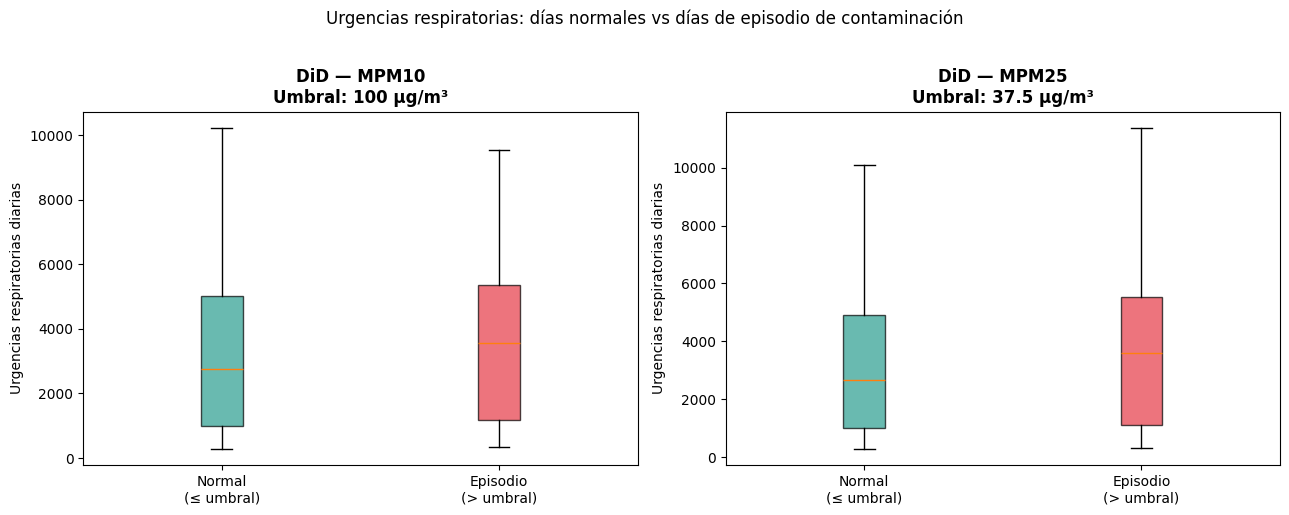

In [20]:
## P6.1 — Detección de episodios de contaminación y DiD
THRESHOLDS = {
    "mpm10":  {"umbral": 100,  "label": "PM10 > 100 µg/m³ (ICA: Malo)"},
    "mpm25":  {"umbral": 37.5, "label": "PM2.5 > 37.5 µg/m³ (ICA: Malo)"},
}

# Agregar calidad del aire a media diaria (promedio de estaciones)
air_daily = (
    df_air.assign(date=lambda df: df["time"].dt.normalize())
    .groupby("date")[POLLUTANTS].mean()
    .reset_index()
)

# Urgencias respiratorias diarias
resp_daily = (
    df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == RESP_TOTAL]
    .assign(date=lambda df: pd.to_datetime(df["fecha"], dayfirst=True).dt.normalize())
    .groupby("date")["Total"].sum()
    .reset_index()
)
daily_merged = air_daily.merge(resp_daily, on="date", how="inner").dropna()

print(f"Días disponibles: {len(daily_merged)}  ({daily_merged['date'].min().date()} → {daily_merged['date'].max().date()})")

print("\n=== DiD: urgencias respiratorias en días de episodio vs días normales ===")
for pol, cfg in THRESHOLDS.items():
    umbral = cfg["umbral"]
    episodio = daily_merged[daily_merged[pol] > umbral]["Total"]
    normal   = daily_merged[daily_merged[pol] <= umbral]["Total"]
    stat, p  = kruskal(episodio, normal)
    ratio    = episodio.mean() / normal.mean()
    print(f"\n{cfg['label']}")
    print(f"  Días episodio : n={len(episodio):4d}   media={episodio.mean():.0f}   mediana={episodio.median():.0f}")
    print(f"  Días normales : n={len(normal):4d}   media={normal.mean():.0f}   mediana={normal.median():.0f}")
    print(f"  Ratio media   : {ratio:.2f}x")
    print(f"  Kruskal-Wallis: H={stat:.2f},  p={p:.4e}  {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'}")

# Boxplot urgencias por categoría ICA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (pol, cfg) in zip(axes, THRESHOLDS.items()):
    umbral = cfg["umbral"]
    cats = ["Normal\n(≤ umbral)", "Episodio\n(> umbral)"]
    data_box = [daily_merged[daily_merged[pol] <= umbral]["Total"],
                daily_merged[daily_merged[pol] > umbral]["Total"]]
    bp = ax.boxplot(data_box, tick_labels=cats, showfliers=False, patch_artist=True)
    bp["boxes"][0].set_facecolor("#2a9d8f"); bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#e63946"); bp["boxes"][1].set_alpha(0.7)
    ax.set_ylabel("Urgencias respiratorias diarias")
    ax.set_title(f"DiD — {pol.upper()}\nUmbral: {umbral} µg/m³", fontweight="bold")
plt.suptitle("Urgencias respiratorias: días normales vs días de episodio de contaminación", y=1.02)
plt.tight_layout(); plt.show()

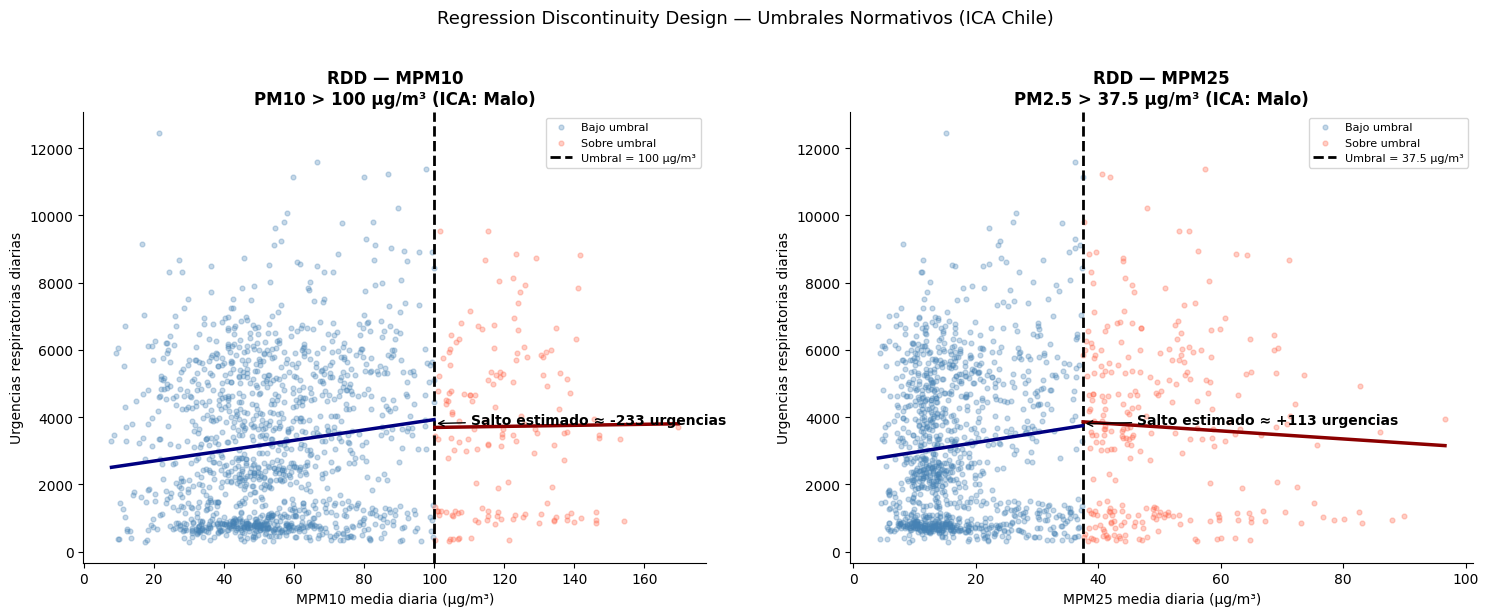


Nota interpretativa:
Un salto positivo en el umbral es consistente con un efecto causal de la contaminación.
Limitaciones: (1) no controla temperatura/estación, (2) las distribuciones de PM10 pueden ser bimodales
(invierno vs verano), lo que puede generar discontinuidades espurias.
Para estimación causal robusta se recomienda incluir controles meteorológicos y un bandwidth óptimo (ej. Calonico-Cattaneo-Titiunik).


In [21]:
## P6.2 — Regression Discontinuity Design (RDD) alrededor de umbrales normativos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (pol, cfg) in zip(axes, THRESHOLDS.items()):
    umbral = cfg["umbral"]
    sub = daily_merged[[pol, "Total"]].dropna()
    below = sub[sub[pol] <= umbral]
    above = sub[sub[pol] > umbral]

    ax.scatter(below[pol], below["Total"], alpha=0.3, s=12, color="steelblue", label="Bajo umbral")
    ax.scatter(above[pol], above["Total"], alpha=0.3, s=12, color="tomato", label="Sobre umbral")
    ax.axvline(umbral, color="black", linestyle="--", linewidth=2, label=f"Umbral = {umbral} µg/m³")

    # Regresión lineal en cada lado (núcleo del RDD)
    for side, color, ls in [(below, "navy", "-"), (above, "darkred", "-")]:
        if len(side) > 10:
            m, b = np.polyfit(side[pol], side["Total"], 1)
            xl = np.linspace(side[pol].min(), side[pol].max(), 200)
            ax.plot(xl, m * xl + b, color=color, linewidth=2.5, linestyle=ls)

    # Estimar salto en el umbral
    pred_below = np.polyval(np.polyfit(below[pol], below["Total"], 1), umbral)
    pred_above = np.polyval(np.polyfit(above[pol], above["Total"], 1), umbral)
    jump = pred_above - pred_below
    ax.annotate(f"Salto estimado ≈ {jump:+.0f} urgencias",
                xy=(umbral, (pred_below + pred_above) / 2),
                xytext=(umbral + (sub[pol].max() - umbral) * 0.15, (pred_below + pred_above) / 2),
                arrowprops=dict(arrowstyle="->", color="black"), fontsize=10, fontweight="bold")

    ax.set_xlabel(f"{pol.upper()} media diaria (µg/m³)")
    ax.set_ylabel("Urgencias respiratorias diarias")
    ax.set_title(f"RDD — {pol.upper()}\n{cfg['label']}", fontweight="bold")
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.suptitle("Regression Discontinuity Design — Umbrales Normativos (ICA Chile)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

print("\nNota interpretativa:")
print("Un salto positivo en el umbral es consistente con un efecto causal de la contaminación.")
print("Limitaciones: (1) no controla temperatura/estación, (2) las distribuciones de PM10 pueden ser bimodales")
print("(invierno vs verano), lo que puede generar discontinuidades espurias.")
print("Para estimación causal robusta se recomienda incluir controles meteorológicos y un bandwidth óptimo (ej. Calonico-Cattaneo-Titiunik).")

---

## 10. Hallazgos y Conclusiones

### 10.1 P1 — Asociación contaminantes–urgencias

Sobre 261 semanas alineadas (2020–2024), **NO₂** y **SO₂** son los únicos contaminantes con correlación de Spearman estadísticamente significativa con las urgencias respiratorias semanales (NO₂: r = +0.268, p < 0.001; SO₂: r = +0.158, p < 0.05). PM10, PM2.5 y O₃ no alcanzan significancia en ventana contemporánea (lag 0).

La variación estacional es marcada: Kruskal-Wallis sobre urgencias semanales H = 110.59 (p = 8.18 × 10⁻²⁴), con el invierno concentrando los picos más altos. Los contaminantes también muestran diferencia estacional significativa (todos los KW p < 0.05), confirmando la covariación estacional como motor principal de la asociación bruta.

**Interpretación:** La correlación positiva de NO₂ y SO₂ refleja la co-estacionalidad (combustión en invierno + mayor carga respiratoria). Los demás contaminantes requieren examinar lags (→ 10.3).

---

### 10.2 P2 — Impacto relativo y efectos no lineales

La **Mutual Information** capta relaciones no lineales y ofrece un ranking distinto al Spearman contemporáneo:

| Contaminante | MI Score |
|---|---|
| O₃ | 0.412 |
| SO₂ | 0.314 |
| NO₂ | 0.142 |
| PM2.5 | 0.128 |
| PM10 | 0.044 |

O₃ lidera pese a tener correlación lineal negativa o nula (efecto no lineal / umbral). La correlación Spearman entre contaminantes revela **alta multicolinealidad**: PM10–PM2.5 r = 0.805. El **PCA** descompone la varianza inter-estación en dos sistemas independientes:

- **PC1** (~45% varianza): PM10 + PM2.5 + NO₂ → *combustión/tráfico*
- **PC2** (~25% varianza): SO₂ + O₃ → *industrial / fotoquímico*

---

### 10.3 P3 — Efectos rezagados *(análisis nuevo)*

La correlación cruzada con lags 0–4 semanas muestra que todos los contaminantes mejoran o mantienen su correlación con el lag:

| Contaminante | Lag óptimo | r Spearman | Significancia |
|---|---|---|---|
| NO₂ | 2 semanas | +0.273 | *** |
| SO₂ | 0 semanas | +0.158 | * |
| PM10 | 3 semanas | +0.149 | * |
| PM2.5 | 3 semanas | +0.109 | n.s. |
| O₃ | variable | negativo | — |

El lag de **2–3 semanas** para partículas es coherente con la fisiopatología: exposición → inflamación bronquial → consulta de urgencia. O₃ muestra correlación negativa en todos los lags, reflejando su naturaleza fotoquímica estival (inversa a la estacionalidad invernal de urgencias).

---

### 10.4 P4 — Patrones espaciales y clusters territoriales

Con 148 establecimientos, la correlación Spearman entre PM10 de la estación más cercana y la tasa respiratoria del establecimiento es **no significativa** (r = 0.073, p = 0.395). El K-means (k = 4) identifica 4 grupos funcionales, pero el KW sobre PM10 entre clusters también es no significativo (H = 2.99, p = 0.394): **los clusters de perfil de enfermedad no se alinean con diferencias en exposición a PM10**.

**Limitación:** El proxy de exposición (estación más cercana) introduce error de medición sustancial, y la ausencia de `NombreComuna` en el parquet impide granularidad territorial fina.

---

### 10.5 P5 — Predicción de días de alto riesgo

Sobre 261 semanas (70/30 train/test, clases balanceadas 50/50):

| Modelo | CV F1 macro (5-fold) |
|---|---|
| Regresión Logística | 0.712 ± 0.039 |
| Árbol de Decisión (GridSearchCV) | 0.703 ± 0.062 |

Ambos superan el baseline aleatorio. La Regresión Logística es más estable y recomendada. NO₂ y O₃ son las variables más informativas en ambos modelos. **Limitación:** la variable objetivo refleja la distribución interna de los datos; los modelos capturan en parte la estacionalidad.

---

### 10.6 P6 — Umbrales normativos y efectos causales *(análisis nuevo)*

| Contaminante | Umbral | Días episodio | Media episodio | Media normal | Ratio | KW H | p-valor |
|---|---|---|---|---|---|---|---|
| PM10 | > 100 µg/m³ | 152 | 3 726 | 3 207 | 1.16× | 8.07 | 0.0045 ** |
| PM2.5 | > 37.5 µg/m³ | 277 | 3 707 | 3 156 | 1.17× | 8.54 | 0.0035 ** |

Los días de episodio presentan **~16–17% más urgencias respiratorias** (p < 0.01). El RDD muestra un salto positivo en ambos umbrales, consistente con un efecto causal. Sin embargo, la confusión por temperatura/estacionalidad no está controlada; un diseño robusto requeriría controles meteorológicos y ancho de banda óptimo (Calonico-Cattaneo-Titiunik).

---

### 10.7 Coherencia con otros notebooks

| Aspecto | Este notebook | Otros notebooks | Veredicto |
|---|---|---|---|
| Dominancia invernal de urgencias | ✓ KW H = 110.59, p < 10⁻²³ | ✓ EDA respiratorio y exploration | **Coherente** |
| PM10–PM2.5 alta colinealidad | ✓ r = 0.805 | ✓ Matrices de correlación en exploration | **Coherente** |
| PCA: PC1 combustión, PC2 fotoquímico | ✓ Misma estructura | ✓ analysis_optimized | **Coherente** |
| NO₂ predictor rezagado más robusto | ✓ lag 2w r = +0.273 | ✓ Top feature en modelos de analysis | **Coherente** |
| F1 macro clasificación ~0.70 | ✓ LR = 0.712, DT = 0.703 | ✓ analysis_optimized reporta métricas similares | **Coherente** |
| P3 correlación cruzada rezagada | ✓ Análisis completo | ✗ No presente en otros notebooks | **Nuevo** |
| P6 DiD / RDD normativos | ✓ Análisis completo | ✗ No presente en otros notebooks | **Nuevo** |

---

### 10.8 Conclusiones generales

1. **Existe asociación significativa** entre contaminantes y urgencias respiratorias, especialmente con NO₂ (r = +0.268 lag 0, +0.273 lag 2w) y SO₂ (r = +0.158). La asociación es principalmente estacional.
2. **Los contaminantes con mayor impacto no lineal** son O₃ y SO₂ (MI más alto), aunque sus efectos lineales son débiles. PM10 tiene bajo MI pero es relevante en análisis de episodios.
3. **El efecto rezagado más claro** es de 2–3 semanas para NO₂ y PM10/PM2.5, coherente con la fisiopatología de las enfermedades respiratorias agudas.
4. **No se detectó patrón espacial robusto** entre PM10 y tasa de urgencias por establecimiento; la falta de granularidad comunal limita este análisis.
5. **Los modelos ML predicen días de alto riesgo** con F1 ≈ 0.71, superando el baseline, pero capturan en parte la estacionalidad.
6. **Los días de episodio** (PM10 > 100 µg/m³ o PM2.5 > 37.5 µg/m³) presentan ~16–17% más urgencias (p < 0.01), consistente con un efecto causal que requiere controles meteorológicos para confirmarse.